## Downloading Dataset

#### resolve csv.gz.icloud issue after downloading files from google drive using gdown

To download the files use the following commands:

```
pip install gdown

gdown --folder --id 1lHg9ryOGtWuQjIULlrjDFbThfDNc44Y-
```

In [24]:
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import pandas as pd

import os
print('-'*40, 'hosp', '-'*40)
path = "./dataset/mimic4/hosp"
for i in os.listdir(path):
    print(i)
print('-'*40, 'icu', '-'*40)
path = "./dataset/mimic4/icu"
for i in os.listdir(path):
    print(i)

---------------------------------------- hosp ----------------------------------------
d_hcpcs.csv.gz
.poe_detail.csv.gz.icloud
patients.csv.gz
.DS_Store
.hcpcsevents.csv.gz.icloud
diagnoses_icd.csv.gz
emar_detail.csv.gz
.prescriptions.csv.gz.icloud
drgcodes.csv.gz
d_icd_diagnoses.csv.gz
d_labitems.csv.gz
transfers.csv.gz
admissions.csv.gz
.microbiologyevents.csv.gz.icloud
labevents.csv.gz
.poe.csv.gz.icloud
procedures_icd.csv.gz
services.csv.gz
d_icd_procedures.csv.gz
.pharmacy.csv.gz.icloud
.omr.csv.gz.icloud
emar.csv.gz
---------------------------------------- icu ----------------------------------------
.outputevents.csv.gz.icloud
.DS_Store
.datetimeevents.csv.gz.icloud
.ingredientevents.csv.gz.icloud
d_items.csv.gz
chartevents.csv.gz
.procedureevents.csv.gz.icloud
icustays.csv.gz
outputevents.csv.gz


In [25]:
# Core demographic and admission data
patients = pd.read_csv("dataset/mimic4/hosp/patients.csv.gz")
admissions = pd.read_csv("dataset/mimic4/hosp/admissions.csv.gz")

# ICU stays
icustays = pd.read_csv("dataset/mimic4/icu/icustays.csv.gz")

# Diagnoses (optional but useful)
diagnoses = pd.read_csv("dataset/mimic4/hosp/diagnoses_icd.csv.gz")

# Dictionaries for interpretation
d_items = pd.read_csv("dataset/mimic4/icu/d_items.csv.gz")
d_labitems = pd.read_csv("dataset/mimic4/hosp/d_labitems.csv.gz")

# bigger files

# Charted ICU data (vitals)
# cols = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'charttime', 'valuenum']
# chartevents = pd.read_csv("dataset/mimic4/icu/chartevents.csv.gz", usecols=cols)
# import after d_items dataframe is being cleaned

# Lab tests
# cols = ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum']
# #labevents = pd.read_csv("./dataset/mimic4//hosp/labevents.csv.gz", usecols=cols)
# chunks = pd.read_csv("./dataset/mimic4/hosp/labevents.csv.gz", usecols=cols, chunksize=300000, low_memory=False)
# labevents = pd.concat(chunks)

### Bigger Files

Big csv dataset files are:  `/hosp/labevents.csv.gz` and `icu/chartevents.csv.gz`. They cannot be read without splitting in chunks. We decided to read, filter and clean the two dataset as a whole process.

For `/icu/chartevents.csv.gz`, it will be imported after `d_items` dataframe is being cleaned because we need to filter data with **is vital sign** which is stored in `d_items` dataframe.

For `/hosp/labevents.csv.gz`, it will be read in chunks while counting the top 5 most frequent lab events, followed by steps that filter itself with calculated top 5 lab events.

The code will be in the next section **Preprocessing - chartevents** and **Preprocessing - labevents**

## Preprocessing

### patients

Rows: 1 per patient

KeyID: `subject_id`

| Column      | Type       | Description                                              |
|------------|-----------|----------------------------------------------------------|
| `subject_id`  | ID        | Unique patient ID                                      |
| `gender`      | 🔒 Sensitive | Male or Female                                       |
| `anchor_age`  | 🔒 Sensitive | Approximate age at time of admission                |
| `dod`         | 🧠 Label   | Date of death (used with ICU discharge to define ICU mortality) |


In [26]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


In [27]:
print(f'''patients:
{patients.shape}
{'-'*20}
{patients.dtypes}
{'-'*20}
{patients.count()}
{'-'*20}
{patients.isna().sum()}
{'-'*20}
{patients.describe()}
{'-'*20}
''')

patients:
(364627, 6)
--------------------
subject_id            int64
gender               object
anchor_age            int64
anchor_year           int64
anchor_year_group    object
dod                  object
dtype: object
--------------------
subject_id           364627
gender               364627
anchor_age           364627
anchor_year          364627
anchor_year_group    364627
dod                   38301
dtype: int64
--------------------
subject_id                0
gender                    0
anchor_age                0
anchor_year               0
anchor_year_group         0
dod                  326326
dtype: int64
--------------------
         subject_id     anchor_age    anchor_year
count  3.646270e+05  364627.000000  364627.000000
mean   1.501166e+07      48.875097    2150.835404
std    2.885013e+06      20.943316      23.395666
min    1.000003e+07      18.000000    2110.000000
25%    1.251201e+07      29.000000    2131.000000
50%    1.501868e+07      48.000000    2151.000000


In [28]:
# Drop synthetic time columns
patients_clean = patients.copy()
patients_clean = patients_clean.drop(columns=['anchor_year', 'anchor_year_group'])

# Convert gender to binary
patients_clean['gender'] = patients_clean['gender'].map({'M': 1, 'F': 0})

# Convert dod to datetime
patients_clean['dod'] = pd.to_datetime(patients_clean['dod'])

# dod will have many missing values — that’s expected (most patients survived)
print(f'''patients_clean:
{patients_clean.shape}
{'-'*40}
{patients_clean.count()}
{'-'*40}
{patients_clean.isna().sum()}
{'-'*40}
''')
patients_clean.info()
patients_clean.head()

patients_clean:
(364627, 4)
----------------------------------------
subject_id    364627
gender        364627
anchor_age    364627
dod            38301
dtype: int64
----------------------------------------
subject_id         0
gender             0
anchor_age         0
dod           326326
dtype: int64
----------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364627 entries, 0 to 364626
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   subject_id  364627 non-null  int64         
 1   gender      364627 non-null  int64         
 2   anchor_age  364627 non-null  int64         
 3   dod         38301 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(3)
memory usage: 11.1 MB


,subject_id,gender,anchor_age,dod
0,10000032,0,52,2180-09-09
1,10000048,0,23,NaT
2,10000058,0,33,NaT
3,10000068,0,19,NaT
4,10000084,1,72,2161-02-13


minimum age: 18
maximum age: 91
unique values: 73
Age groups:
['50-64' '18-29' '30-49' '65-79' '80-91']
             Count  Percentage (%)
age_grouped                       
18-29        91967           25.22
30-49        96157           26.37
50-64        80788           22.16
65-79        61698           16.92
80-91        34017            9.33


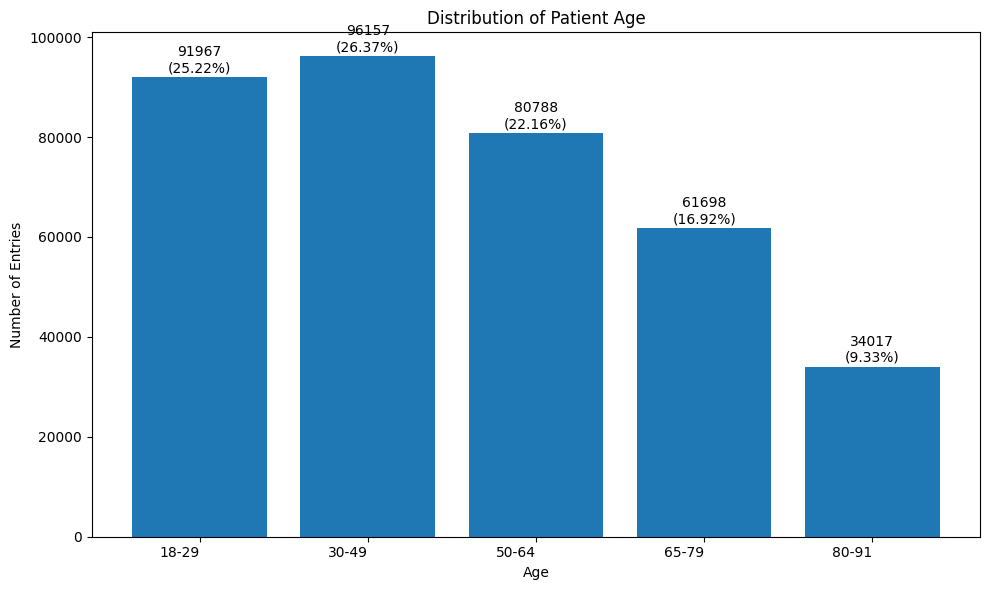

Original shape: (364627, 5)
Encoded shape: (364627, 8)


,subject_id,gender,dod,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91
0,10000032,0,2180-09-09,0.0,0.0,1.0,0.0,0.0
1,10000048,0,NaT,1.0,0.0,0.0,0.0,0.0
2,10000058,0,NaT,0.0,1.0,0.0,0.0,0.0
3,10000068,0,NaT,1.0,0.0,0.0,0.0,0.0
4,10000084,1,2161-02-13,0.0,0.0,0.0,1.0,0.0


In [29]:
# Convert age to age groups and apply one-hot encoding
print(f"minimum age: {patients_clean['anchor_age'].min()}")
print(f"maximum age: {patients_clean['anchor_age'].max()}")
print(f"unique values: {patients_clean['anchor_age'].nunique()}")

def map_age(age_value):
    if age_value < 30:
        return "18-29"
    elif age_value < 50:
        return "30-49"
    elif age_value < 65:
        return "50-64"
    elif age_value < 80:
        return "65-79"
    else:
        return "80-91"

patients_clean['age_grouped'] = patients_clean['anchor_age'].apply(map_age)
print(f"Age groups:\n{patients_clean['age_grouped'].unique()}")
# Count entries for each consolidated category
age_order = ["18-29", "30-49", "50-64", "65-79", "80-91"]
age_group_counts = patients_clean['age_grouped'].value_counts().reindex(age_order)
# Get percentage of each category
age_percentages = (age_group_counts / len(patients_clean) * 100).round(2)
age_stats = pd.DataFrame({
        'Count': age_group_counts,
        'Percentage (%)': age_percentages
    })
print(age_stats)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(age_stats.index, age_stats['Count'])
plt.title('Distribution of Patient Age')
plt.xlabel('Age')
plt.ylabel('Number of Entries')
plt.xticks(ha='right')
plt.tight_layout()

# Add count labels above bars
for i, count in enumerate(age_stats['Count']):
    plt.text(i, count + (max(age_stats['Count'])*0.01), 
                f"{count}\n({age_stats['Percentage (%)'][i]}%)", 
                ha='center')
plt.show()

# Using sklearn OneHotEncoder to apply one-hot encoding
# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Reshape the race column and fit transform
age_array = encoder.fit_transform(patients_clean[['age_grouped']])

# Create a DataFrame with the encoded values
age_encoded_df = pd.DataFrame(
    age_array, 
    columns=[f'age_{age}' for age in encoder.categories_[0]],
    index=patients_clean.index
)

# Concatenate with original dataframe
patients_encoded = pd.concat([patients_clean, age_encoded_df], axis=1)

# drop the original race columns
patients_encoded = patients_encoded.drop(['anchor_age', 'age_grouped'], axis=1)

# Display the shape of the new dataframe
print(f"Original shape: {patients_clean.shape}")
print(f"Encoded shape: {patients_encoded.shape}")
patients_encoded.head()

### admissions

Rows: 1 per hospital admission(hadm_id)

Key IDs: `subject_id`, `hadm_id`

| Column                  | Type                 | Description                                           |
|-------------------------|----------------------|-------------------------------------------------------|
| `subject_id`           | ID                   | Patient ID                                           |
| `hadm_id`             | ID                   | Hospital admission ID                                |
| `ethnicity`           | 🔒 Sensitive         | Patient-reported race/ethnicity                     |
| `insurance`           | 🔒 Sensitive         | Primary insurance type (e.g., Medicaid, Private)    |
| `language`            | 🔒 Sensitive         | Preferred language                                  |
| `marital_status`      | 🔒 Sensitive         | Married, Single, Divorced, etc.                     |
| `admittime / dischtime` | 🧠 Predictive (optional) | Can be used to compute hospital LOS (length of stay) |


In [30]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


In [31]:
print(f'''admissions:
{admissions.shape}
{'-'*20}
{admissions.dtypes}
{'-'*20}
{admissions.count()}
{'-'*20}
{admissions.isna().sum()}
{'-'*20}
{admissions.describe()}
{'-'*20}
''')

admissions:
(546028, 16)
--------------------
subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admit_provider_id       object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
race                    object
edregtime               object
edouttime               object
hospital_expire_flag     int64
dtype: object
--------------------
subject_id              546028
hadm_id                 546028
admittime               546028
dischtime               546028
deathtime                11790
admission_type          546028
admit_provider_id       546024
admission_location      546027
discharge_location      396210
insurance               536673
language                545253
marital_status          532409
race                    546028
edregtime           

In [32]:
cols = ['subject_id', 'hadm_id', 'dischtime',
        # 'insurance', 'language', 'marital_status',
        'race','hospital_expire_flag']

admissions_clean = admissions[cols].copy()

# Convert datetime columns
# admissions_clean['admittime'] = pd.to_datetime(admissions_clean['admittime'])   # no need
admissions_clean['dischtime'] = pd.to_datetime(admissions_clean['dischtime'])

# Fill missing values for sensitive attributes
'''“This particular NaN value has special meaning — it tells us that the information was unknown or missing at the time. 
Instead of dropping or guessing it, we treat it as its own category by converting it into a label like 'UNKNOWN', so the model can process it.”'''
# admissions_clean[['insurance', 'language', 'marital_status']] = admissions_clean[['insurance', 'language', 'marital_status']].fillna('UNKNOWN')

# Preview cleaned data
print(f'''admissions_clean:
{admissions_clean.shape}
{'-'*100}
{admissions_clean.count()}
{'-'*100}
{admissions_clean.isna().sum()}
{'-'*100}
''')
admissions_clean.info()
admissions_clean.head()

admissions_clean:
(546028, 5)
----------------------------------------------------------------------------------------------------
subject_id              546028
hadm_id                 546028
dischtime               546028
race                    546028
hospital_expire_flag    546028
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id              0
hadm_id                 0
dischtime               0
race                    0
hospital_expire_flag    0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546028 entries, 0 to 546027
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   subject_id            546028 non-null  int64         
 1   hadm_id               546028 non-null  int64         
 2   disc

,subject_id,hadm_id,dischtime,race,hospital_expire_flag
0,10000032,22595853,2180-05-07 17:15:00,WHITE,0
1,10000032,22841357,2180-06-27 18:49:00,WHITE,0
2,10000032,25742920,2180-08-07 17:50:00,WHITE,0
3,10000032,29079034,2180-07-25 17:55:00,WHITE,0
4,10000068,25022803,2160-03-04 06:26:00,WHITE,0


In [33]:
# admissions_clean['language'].unique()
admissions_clean['race'].unique()

# Language, insurance, Marital status is removed first to see how it goes
# We'll be analyzing sensitive attributes based on age, gender and race at this time
# race will be consolidated and encoded in one-hot encoding

array(['WHITE', 'OTHER', 'BLACK/AFRICAN AMERICAN', 'UNABLE TO OBTAIN',
       'UNKNOWN', 'WHITE - RUSSIAN', 'BLACK/CAPE VERDEAN',
       'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'PORTUGUESE',
       'WHITE - OTHER EUROPEAN', 'HISPANIC/LATINO - PUERTO RICAN',
       'ASIAN', 'ASIAN - CHINESE', 'HISPANIC/LATINO - DOMINICAN',
       'HISPANIC/LATINO - SALVADORAN', 'BLACK/AFRICAN',
       'HISPANIC/LATINO - GUATEMALAN', 'ASIAN - SOUTH EAST ASIAN',
       'WHITE - BRAZILIAN', 'SOUTH AMERICAN', 'HISPANIC OR LATINO',
       'ASIAN - KOREAN', 'BLACK/CARIBBEAN ISLAND',
       'HISPANIC/LATINO - MEXICAN', 'PATIENT DECLINED TO ANSWER',
       'HISPANIC/LATINO - CUBAN', 'AMERICAN INDIAN/ALASKA NATIVE',
       'MULTIPLE RACE/ETHNICITY', 'WHITE - EASTERN EUROPEAN',
       'HISPANIC/LATINO - HONDURAN', 'HISPANIC/LATINO - CENTRAL AMERICAN',
       'ASIAN - ASIAN INDIAN', 'HISPANIC/LATINO - COLUMBIAN'],
      dtype=object)

Consolidated races:
['WHITE' 'OTHER' 'BLACK' 'UNKNOWN' 'RUSSIAN' 'EUROPEAN' 'HISPANIC/LATINO'
 'ASIAN']
                    Count  Percentage (%)
race_consolidated                        
WHITE              338064           61.91
BLACK               89057           16.31
HISPANIC/LATINO     32210            5.90
OTHER               24385            4.47
UNKNOWN             20106            3.68
ASIAN               19751            3.62
EUROPEAN            15858            2.90
RUSSIAN              6597            1.21


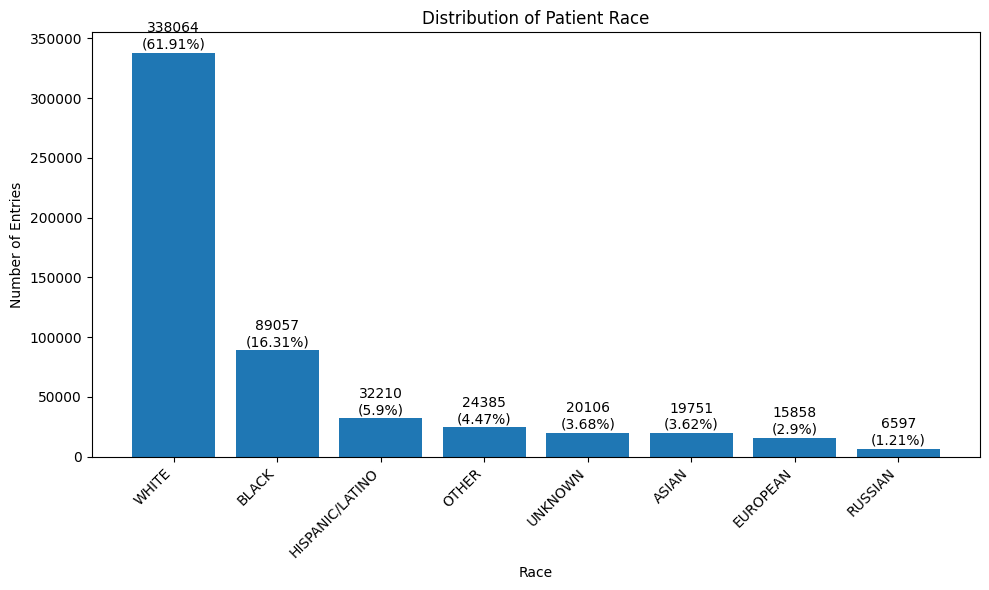

Original shape: (546028, 6)
Encoded shape: (546028, 12)


,subject_id,hadm_id,dischtime,hospital_expire_flag,race_ASIAN,race_BLACK,race_EUROPEAN,race_HISPANIC/LATINO,race_OTHER,race_RUSSIAN,race_UNKNOWN,race_WHITE
0,10000032,22595853,2180-05-07 17:15:00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,10000032,22841357,2180-06-27 18:49:00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,10000032,25742920,2180-08-07 17:50:00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,10000032,29079034,2180-07-25 17:55:00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,10000068,25022803,2160-03-04 06:26:00,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [34]:
def map_race(race_value):
    if pd.isna(race_value):
        return 'UNKNOWN'
    elif 'RUSSIAN' in race_value:
        return 'RUSSIAN'
    elif 'EUROPEAN' in race_value:
        return 'EUROPEAN'
    elif 'WHITE' in race_value:
        return 'WHITE'
    elif 'ASIAN' in race_value:
        return 'ASIAN'
    elif 'HISPANIC/LATINO' in race_value:
        return 'HISPANIC/LATINO'
    elif 'HISPANIC OR LATINO' in race_value:
        return 'HISPANIC/LATINO'
    elif 'BLACK' in race_value:
        return 'BLACK'
    elif race_value in ['PATIENT DECLINED TO ANSWER', 'UNABLE TO OBTAIN', 'UNKNOWN', "MULTIPLE RACE/ETHNICITY"]:
        return 'UNKNOWN'
    elif race_value in ['AMERICAN INDIAN/ALASKA NATIVE', 'NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', "PORTUGUESE", "SOUTH AMERICAN"]:
        return 'OTHER'
    else:
        return race_value

admissions_clean['race_consolidated'] = admissions_clean['race'].apply(map_race)
print(f"Consolidated races:\n{admissions_clean['race_consolidated'].unique()}")
# Count entries for each consolidated category
race_counts = admissions_clean['race_consolidated'].value_counts()
# Get percentage of each category
race_percentages = (race_counts / len(admissions_clean) * 100).round(2)
race_stats = pd.DataFrame({
        'Count': race_counts,
        'Percentage (%)': race_percentages
    })
print(race_stats)

# Create a bar plot
plt.figure(figsize=(10, 6))
plt.bar(race_stats.index, race_stats['Count'])
plt.title('Distribution of Patient Race')
plt.xlabel('Race')
plt.ylabel('Number of Entries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Add count labels above bars
for i, count in enumerate(race_stats['Count']):
    plt.text(i, count + (max(race_stats['Count'])*0.01), 
                f"{count}\n({race_stats['Percentage (%)'][i]}%)", 
                ha='center')
plt.show()

# Using sklearn OneHotEncoder to apply one-hot encoding
# Initialize the encoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Reshape the race column and fit transform
race_array = encoder.fit_transform(admissions_clean[['race_consolidated']])

# Create a DataFrame with the encoded values
race_encoded_df = pd.DataFrame(
    race_array, 
    columns=[f'race_{race}' for race in encoder.categories_[0]],
    index=admissions_clean.index
)

# Concatenate with original dataframe
admissions_encoded = pd.concat([admissions_clean, race_encoded_df], axis=1)

# drop the original race columns
admissions_encoded = admissions_encoded.drop(['race', 'race_consolidated'], axis=1)

# Display the shape of the new dataframe
print(f"Original shape: {admissions_clean.shape}")
print(f"Encoded shape: {admissions_encoded.shape}")
admissions_encoded.head()

### icustays

Rows: 1 per ICU stay

Key IDs: `subject_id`, `hadm_id`, `stay_id`

| Column      | Type             | Description                                                        |
|-------------|------------------|--------------------------------------------------------------------|
| subject_id  | ID               | Patient ID                                                         |
| hadm_id     | ID               | Hospital admission ID                                              |
| stay_id     | ID               | ICU stay ID                                                        |
| intime      | 🔮 Predictive    | ICU admission timestamp                                            |
| outtime     | 🔮 Predictive & Label | ICU discharge timestamp; used with `dod` to compute ICU mortality (`dod ≤ outtime`) |

In [35]:
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [36]:
print(f'''icustays:
{icustays.shape}
{'-'*20}
{icustays.dtypes}
{'-'*20}
{icustays.count()}
{'-'*20}
{icustays.isna().sum()}
{'-'*20}
{icustays.describe()}
{'-'*20}
''')

icustays:
(94458, 8)
--------------------
subject_id          int64
hadm_id             int64
stay_id             int64
first_careunit     object
last_careunit      object
intime             object
outtime            object
los               float64
dtype: object
--------------------
subject_id        94458
hadm_id           94458
stay_id           94458
first_careunit    94458
last_careunit     94458
intime            94458
outtime           94444
los               94444
dtype: int64
--------------------
subject_id         0
hadm_id            0
stay_id            0
first_careunit     0
last_careunit      0
intime             0
outtime           14
los               14
dtype: int64
--------------------
         subject_id       hadm_id       stay_id           los
count  9.445800e+04  9.445800e+04  9.445800e+04  94444.000000
mean   1.500422e+07  2.498185e+07  3.499832e+07      3.630025
std    2.884050e+06  2.884066e+06  2.886407e+06      5.402474
min    1.000003e+07  2.000009e+07  3.00

In [37]:
'''Don't use los for ICU mortality prediction because it creates a leakage risk.
If someone dies early, their los will be very short → model might learn to predict death from low los directly.
You want to predict it based on vitals, labs, and demographics available early, so use los for descriptive statistics and filtering out noise'''


# You can’t define ICU mortality without outtime so drop those missing rows
# Drops entire rows where the column outtime is NaN
icustays_clean = icustays.copy()
icustays_clean = icustays_clean.dropna(subset=['outtime'])

# Convert intime and outtime to datetime
icustays_clean['intime'] = pd.to_datetime(icustays_clean['intime'])
icustays_clean['outtime'] = pd.to_datetime(icustays_clean['outtime'])

cols = ['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'los']
icustays_clean = icustays_clean[cols]

# Preview cleaned data
print(f'''icustays_clean:
{icustays_clean.shape}
{'-'*100}
{icustays_clean.count()}
{'-'*100}
{icustays_clean.isna().sum()}
{'-'*100}
''')
icustays_clean.info()
icustays_clean.head()

icustays_clean:
(94444, 6)
----------------------------------------------------------------------------------------------------
subject_id    94444
hadm_id       94444
stay_id       94444
intime        94444
outtime       94444
los           94444
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id    0
hadm_id       0
stay_id       0
intime        0
outtime       0
los           0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 94444 entries, 0 to 94457
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   subject_id  94444 non-null  int64         
 1   hadm_id     94444 non-null  int64         
 2   stay_id     94444 non-null  int64         
 3   intime      94444 non-null  datetime64[ns]
 4   outtime     94444 non-null  dat

,subject_id,hadm_id,stay_id,intime,outtime,los
0,10000032,29079034,39553978,2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


### diagnoses

Rows: 1 per diagnosis

Key IDs: `subject_id`, `hadm_id`

| Column      | Type             | Description         |
|-------------|------------------|---------------------|
| subject_id  | ID               | Patient ID            |
| hadm_id     | ID               | Hospital admission ID             |
| seq_num     | label       |A pseudo-order for the ICD codes within a stay (1 most relevant, 9 the least)  |
| icd_code      | label    | The coded representation of the diagnosis using the ICD ontology      |
| icd_version   | label | The textual description of the ICD code |

In [38]:
diagnoses.head()

,subject_id,hadm_id,seq_num,icd_code,icd_version
0,10000032,22595853,1,5723,9
1,10000032,22595853,2,78959,9
2,10000032,22595853,3,5715,9
3,10000032,22595853,4,07070,9
4,10000032,22595853,5,496,9


In [39]:
print(f'''diagnoses:
{diagnoses.shape}
{'-'*20}
{diagnoses.dtypes}
{'-'*20}
{diagnoses.count()}
{'-'*20}
{diagnoses.isna().sum()}
{'-'*20}
{diagnoses.describe()}
{'-'*20}
''')

diagnoses:
(6364488, 5)
--------------------
subject_id      int64
hadm_id         int64
seq_num         int64
icd_code       object
icd_version     int64
dtype: object
--------------------
subject_id     6364488
hadm_id        6364488
seq_num        6364488
icd_code       6364488
icd_version    6364488
dtype: int64
--------------------
subject_id     0
hadm_id        0
seq_num        0
icd_code       0
icd_version    0
dtype: int64
--------------------
         subject_id       hadm_id       seq_num   icd_version
count  6.364488e+06  6.364488e+06  6.364488e+06  6.364488e+06
mean   1.500237e+07  2.500059e+07  8.825529e+00  9.542973e+00
std    2.878400e+06  2.889094e+06  6.858762e+00  4.981499e-01
min    1.000003e+07  2.000002e+07  1.000000e+00  9.000000e+00
25%    1.251032e+07  2.249520e+07  4.000000e+00  9.000000e+00
50%    1.500206e+07  2.500402e+07  7.000000e+00  1.000000e+01
75%    1.750180e+07  2.750210e+07  1.200000e+01  1.000000e+01
max    1.999999e+07  2.999994e+07  3.900000e+0

In [40]:
# Charlson/Elixhauser handle ICD-9 only — pre-filter ICD-9 to exclude ICD-10
diagnoses_clean = diagnoses[diagnoses['icd_version'] == 9].copy()

cols = ['subject_id', 'hadm_id', 'icd_code']
diagnoses_clean = diagnoses_clean[cols]

# Convert icd_code to string and standardize format
diagnoses_clean = diagnoses_clean[cols]
diagnoses_clean['icd_code'] = diagnoses_clean['icd_code'].astype(str).str.strip().str.upper()

# Preview cleaned data
print(f'''diagnoses_clean:
{diagnoses_clean.shape}
{'-'*100}
{diagnoses_clean.count()}
{'-'*100}
{diagnoses_clean.isna().sum()}
{'-'*100}
''')
diagnoses_clean.info()
diagnoses_clean.head()

diagnoses_clean:
(2908741, 3)
----------------------------------------------------------------------------------------------------
subject_id    2908741
hadm_id       2908741
icd_code      2908741
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id    0
hadm_id       0
icd_code      0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 2908741 entries, 0 to 6364487
Data columns (total 3 columns):
 #   Column      Dtype 
---  ------      ----- 
 0   subject_id  int64 
 1   hadm_id     int64 
 2   icd_code    object
dtypes: int64(2), object(1)
memory usage: 88.8+ MB


,subject_id,hadm_id,icd_code
0,10000032,22595853,5723
1,10000032,22595853,78959
2,10000032,22595853,5715
3,10000032,22595853,07070
4,10000032,22595853,496


### labevents

Rows: Time-stamped lab measurements

Key IDs: `subject_id`, `hadm_id`

| Column                | Type          | Description                                      |
|-----------------------|---------------|--------------------------------------------------|
| subject_id, hadm_id   | ID            | For joining and grouping                         |
| itemid                | Lookup        | Lab test code (mapped via `d_labitems.csv.gz`)   |
| charttime             | Time          | When the lab was drawn                           |
| valuenum              | 🔮 Predictive  | Numeric result (e.g., WBC = 12.3)                |

In [41]:
# # Lab tests
# cols = ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum']
# #labevents = pd.read_csv("./dataset/mimic4//hosp/labevents.csv.gz", usecols=cols)
# chunks = pd.read_csv("./dataset/mimic4/hosp/labevents.csv.gz", usecols=cols, chunksize=300000, low_memory=False)
# labevents = pd.concat(chunks)

# labevents.head()

In [42]:
# print(f'''labevents:
# {labevents.shape}
# {'-'*20}
# {labevents.dtypes}
# {'-'*20}
# {labevents.count()}
# {'-'*20}
# {labevents.isna().sum()}
# {'-'*20}
# {labevents["valuenum"].describe()}
# {'-'*20}
# ''')

In [43]:
# # Drop rows without numeric values (non-numeric test results)
# labevents_clean = labevents.dropna(subset=['valuenum']).copy()

# # top 5 most frequent lab itemid values
# top5 = labevents_clean['itemid'].value_counts().head(5).index.tolist()
# labevents_clean = labevents_clean[labevents_clean['itemid'].isin(top5)].copy()

# labevents_clean['charttime'] = pd.to_datetime(labevents_clean['charttime'])

# # Preview cleaned data
# labevents_clean.info()
# labevents_clean.head()

In [44]:
# read and filter top 5 lab events

# First pass: aggregate counts for each itemid across chunks

chunksize = 100000
itemid_counts = pd.Series(dtype='int64')

for chunk in pd.read_csv('./dataset/mimic4/hosp/labevents.csv.gz', chunksize=chunksize, low_memory=False):
    # Drop rows without numeric 'valuenum'
    chunk = chunk.dropna(subset=['valuenum'])
    itemid_counts = itemid_counts.add(chunk['itemid'].value_counts(), fill_value=0)

# Determine the top 5 most frequent itemids
top5 = itemid_counts.nlargest(5).index.tolist()

In [45]:
top5

[51221, 50912, 51006, 51265, 51222]

In [46]:
# Second pass: filter by top 5 lab events

chunks = []

# Second pass: filter rows that belong to the top 5 itemids
for chunk in pd.read_csv('./dataset/mimic4/hosp/labevents.csv.gz', chunksize=50000, 
                         on_bad_lines='skip', compression='gzip'):
    chunk = chunk.dropna(subset=['valuenum'])
    chunk = chunk[chunk['itemid'].isin(top5)]
    chunks.append(chunk)

# Concatenate the filtered chunks
labevents_clean = pd.concat(chunks, ignore_index=True)

# Convert charttime to datetime
labevents_clean['charttime'] = pd.to_datetime(labevents_clean['charttime'])

# Preview the cleaned data
print(f'''labevents_clean:
{labevents_clean.shape}
{'-'*100}
{labevents_clean.count()}
{'-'*100}
{labevents_clean.isna().sum()}
{'-'*100}
''')
labevents_clean.info()
labevents_clean.head()

labevents_clean:
(21209243, 16)
----------------------------------------------------------------------------------------------------
labevent_id          21209243
subject_id           21209243
hadm_id              12621837
specimen_id          21209243
itemid               21209243
order_provider_id     5571146
charttime            21209243
storetime            21209241
value                21209243
valuenum             21209243
valueuom             21209238
ref_range_lower      21209238
ref_range_upper      21209238
flag                 10441842
priority             21209238
comments               201323
dtype: int64
----------------------------------------------------------------------------------------------------
labevent_id                 0
subject_id                  0
hadm_id               8587406
specimen_id                 0
itemid                      0
order_provider_id    15638097
charttime                   0
storetime                   2
value                       0
val

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,26,10000032,NaN,83925500,50912,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,0.4,0.4,mg/dL,0.4,1.1,NaN,ROUTINE,NaN
1,46,10000032,NaN,83925500,51006,P69FQC,2180-03-23 11:51:00,2180-03-23 16:40:00,13,13.0,mg/dL,6.0,20.0,NaN,ROUTINE,NaN
2,51,10000032,NaN,91029538,51221,P69FQC,2180-03-23 11:51:00,2180-03-23 15:19:00,45.4,45.4,%,36.0,48.0,NaN,ROUTINE,NaN
3,52,10000032,NaN,91029538,51222,P69FQC,2180-03-23 11:51:00,2180-03-23 15:19:00,14.9,14.9,g/dL,12.0,16.0,NaN,ROUTINE,NaN
4,59,10000032,NaN,91029538,51265,P69FQC,2180-03-23 11:51:00,2180-03-23 16:09:00,___,83.0,K/uL,150.0,440.0,abnormal,ROUTINE,VERIFIED BY SMEAR.


### d_items

Rows: One per itemid(dictionary)

Key: `itemid`

| Column   | Type              | Description                                              |
|----------|-------------------|----------------------------------------------------------|
| itemid   | Lookup            | Numeric code used in `chartevents.csv.gz`                |
| label    | Descriptive       | Human-readable label like "Heart Rate", "SpO2", etc.     |
| category | Optional grouping | Sometimes helpful (e.g., "Vitals", "Labs", "Ventilation") |

In [47]:
d_items.head()

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220001,Problem List,Problem List,chartevents,General,NaN,Text,NaN,NaN
1,220003,ICU Admission date,ICU Admission date,datetimeevents,ADT,NaN,Date and time,NaN,NaN
2,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
3,220046,Heart rate Alarm - High,HR Alarm - High,chartevents,Alarms,bpm,Numeric,NaN,NaN
4,220047,Heart Rate Alarm - Low,HR Alarm - Low,chartevents,Alarms,bpm,Numeric,NaN,NaN


In [48]:
print(f'''d_items:
{d_items.shape}
{'-'*20}
{d_items.dtypes}
{'-'*20}
{d_items.count()}
{'-'*20}
{d_items.isna().sum()}
{'-'*20}
{d_items.iloc[:, -2:].describe()}
{'-'*20}
''')

d_items:
(4095, 9)
--------------------
itemid               int64
label               object
abbreviation        object
linksto             object
category            object
unitname            object
param_type          object
lownormalvalue     float64
highnormalvalue    float64
dtype: object
--------------------
itemid             4095
label              4095
abbreviation       4095
linksto            4095
category           4095
unitname           1123
param_type         4095
lownormalvalue       19
highnormalvalue      22
dtype: int64
--------------------
itemid                0
label                 0
abbreviation          0
linksto               0
category              0
unitname           2972
param_type            0
lownormalvalue     4076
highnormalvalue    4073
dtype: int64
--------------------
       lownormalvalue  highnormalvalue
count       19.000000        22.000000
mean        65.000000       133.640909
std        107.356623       253.076007
min         -2.000000     

In [49]:
# Filter only rows that belong to chartevents
d_items_clean = d_items.copy()
d_items_clean = d_items_clean[d_items_clean['linksto'] == 'chartevents']

# Create a binary flag: is_vital_sign
# for category, count in d_items_clean['category'].value_counts().items():
#     print(category, count)

d_items_clean['is_vital_sign'] = (d_items_clean['category'] == 'Routine Vital Signs').map({True: 1, False: 0})

# drop linksto, category after filtering and other unneeded columns 
cols = ['itemid', 'label', 'is_vital_sign']
d_items_clean = d_items_clean[cols]

# Preview cleaned data
# Preview cleaned data
print(f'''d_items_clean:
{d_items_clean.shape}
{'-'*100}
{d_items_clean.count()}
{'-'*100}
{d_items_clean.isna().sum()}
{'-'*100}
''')
d_items_clean.info()
d_items_clean.head()

d_items_clean:
(3055, 3)
----------------------------------------------------------------------------------------------------
itemid           3055
label            3055
is_vital_sign    3055
dtype: int64
----------------------------------------------------------------------------------------------------
itemid           0
label            0
is_vital_sign    0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 3055 entries, 0 to 4094
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   itemid         3055 non-null   int64 
 1   label          3055 non-null   object
 2   is_vital_sign  3055 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 95.5+ KB


,itemid,label,is_vital_sign
0,220001,Problem List,0
2,220045,Heart Rate,1
3,220046,Heart rate Alarm - High,0
4,220047,Heart Rate Alarm - Low,0
5,220048,Heart Rhythm,1


### chartevents

Rows: Time-stamped vitals & notes

Key IDs: `subject_id`, `hadm_id`, `stay_id`

| Column                  | Type         | Description      |
|-------------------------|--------------|------------------|
| `subject_id`, `hadm_id`, `stay_id`  | ID           | For joining and grouping  |
| `itemid`       | Lookup       | Code for the type of measurement (mapped via  `d_items.csv.gz`)  |
| `charttime`      | Time         | Timestamp of the recorded measurement                      |
| `valuenum`     | 🔮 Predictive | The actual numeric value (e.g., heart rate = 85)          |

In [50]:
# Charted ICU data (vitals)
cols = ['subject_id', 'hadm_id', 'stay_id', 'itemid', 'charttime', 'valuenum']
# chartevents = pd.read_csv("dataset/mimic4/icu/chartevents.csv.gz", usecols=cols)

# The above line raises MemoryError because dataset too large, use following method
# Define the important itemid values for vital signs (adjust based on d_items.csv.gz)
# vital_signs_itemids = [220045, 220210, 220277, 220739, 223761]  # Example: HR, BP, RR, SpO2, GCS
# get all item ids with vital signs:
vital_signs_itemids = d_items_clean[d_items_clean['is_vital_sign'] == 1]['itemid'].unique()

# Read in chunks and filter
chunk_size = 500000
chunks = pd.read_csv("dataset/mimic4/icu/chartevents.csv.gz", usecols=cols, chunksize=chunk_size)

# Filter chunks and concatenate
chartevents = pd.concat(chunk[chunk["itemid"].isin(vital_signs_itemids)] for chunk in chunks)

In [51]:
chartevents.head()

,subject_id,hadm_id,stay_id,charttime,itemid,valuenum
3,10000032,29079034,39553978,2180-07-23 14:00:00,220048,NaN
4,10000032,29079034,39553978,2180-07-23 14:00:00,224642,NaN
5,10000032,29079034,39553978,2180-07-23 14:00:00,224650,NaN
6,10000032,29079034,39553978,2180-07-23 14:00:00,223761,98.7
7,10000032,29079034,39553978,2180-07-23 14:11:00,220179,84.0


In [52]:
print(f'''chartevents:
{chartevents.shape}
{'-'*20}
{chartevents.dtypes}
{'-'*20}
{chartevents.count()}
{'-'*20}
{chartevents.isna().sum()}
{'-'*20}
{chartevents.describe()}
{'-'*20}
''')

chartevents:
(57186744, 6)
--------------------
subject_id      int64
hadm_id         int64
stay_id         int64
charttime      object
itemid          int64
valuenum      float64
dtype: object
--------------------
subject_id    57186744
hadm_id       57186744
stay_id       57186744
charttime     57186744
itemid        57186744
valuenum      38336836
dtype: int64
--------------------
subject_id           0
hadm_id              0
stay_id              0
charttime            0
itemid               0
valuenum      18849908
dtype: int64
--------------------
         subject_id       hadm_id       stay_id        itemid      valuenum
count  5.718674e+07  5.718674e+07  5.718674e+07  5.718674e+07  3.833684e+07
mean   1.501599e+07  2.500102e+07  3.497461e+07  2.213126e+05  8.807656e+01
std    2.892542e+06  2.871321e+06  2.884536e+06  2.068132e+03  2.995605e+03
min    1.000003e+07  2.000009e+07  3.000015e+07  2.200450e+05 -2.413950e+05
25%    1.251590e+07  2.251484e+07  3.247888e+07  2.200480e+05

In [53]:
# Drop rows where the measurement is missing
'''Over 400 million rows. But only ~169 million rows have numeric values in valuenum
The rest (263M) are textual observations, equipment notes, categories, etc.'''
chartevents_clean = chartevents.dropna(subset=['valuenum']).copy()
chartevents_clean['charttime'] = pd.to_datetime(chartevents_clean['charttime'])

# chartevents have filtered vital signs only during chunk reading
# top 5 most frequent itemid values
top5 = chartevents_clean['itemid'].value_counts().head(5).index.tolist()
chartevents_vital = chartevents_clean[chartevents_clean['itemid'].isin(top5)].copy()

# Preview cleaned data
print(f'''chartevents_clean:
{chartevents_vital.shape}
{'-'*100}
{chartevents_vital.count()}
{'-'*100}
{chartevents_vital.isna().sum()}
{'-'*100}
''')
chartevents_vital.info()
chartevents_vital.head()

chartevents_clean:
(27978354, 6)
----------------------------------------------------------------------------------------------------
subject_id    27978354
hadm_id       27978354
stay_id       27978354
charttime     27978354
itemid        27978354
valuenum      27978354
dtype: int64
----------------------------------------------------------------------------------------------------
subject_id    0
hadm_id       0
stay_id       0
charttime     0
itemid        0
valuenum      0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 27978354 entries, 7 to 432997414
Data columns (total 6 columns):
 #   Column      Dtype         
---  ------      -----         
 0   subject_id  int64         
 1   hadm_id     int64         
 2   stay_id     int64         
 3   charttime   datetime64[ns]
 4   itemid      int64         
 5   valuenum    float64       
dtypes: datetime64[ns](1), float64(1)

,subject_id,hadm_id,stay_id,charttime,itemid,valuenum
7,10000032,29079034,39553978,2180-07-23 14:11:00,220179,84.0
8,10000032,29079034,39553978,2180-07-23 14:11:00,220180,48.0
9,10000032,29079034,39553978,2180-07-23 14:11:00,220181,56.0
10,10000032,29079034,39553978,2180-07-23 14:12:00,220045,91.0
94,10000032,29079034,39553978,2180-07-23 14:30:00,220045,93.0


### d_labitems

Rows: One per lab item

Key: `itemid`

| Column | Type | Description |
|--------| ---- | ----------- |
| `itemid` | Lookup | Lab test code used in `labevents.csv.gz` |
| `label`  | Descriptive | Name like "WBC", "Creatinine", "Sodium", etc. |

In [54]:
d_labitems.head()

,itemid,label,fluid,category
0,50801,Alveolar-arterial Gradient,Blood,Blood Gas
1,50802,Base Excess,Blood,Blood Gas
2,50803,"Calculated Bicarbonate, Whole Blood",Blood,Blood Gas
3,50804,Calculated Total CO2,Blood,Blood Gas
4,50805,Carboxyhemoglobin,Blood,Blood Gas


In [55]:
print(f'''d_labitems:
{d_labitems.shape}
{'-'*20}
{d_labitems.dtypes}
{'-'*20}
{d_labitems.count()}
{'-'*20}
{d_labitems.isna().sum()}
{'-'*20}
''')

d_labitems:
(1650, 4)
--------------------
itemid       int64
label       object
fluid       object
category    object
dtype: object
--------------------
itemid      1650
label       1646
fluid       1650
category    1650
dtype: int64
--------------------
itemid      0
label       4
fluid       0
category    0
dtype: int64
--------------------



In [56]:
# filter only blood tests since Blood labs are more consistent across patients.
# for fluid, count in d_labitems['fluid'].value_counts().items():
#     print(fluid, count)
d_labitems_clean = d_labitems[d_labitems['fluid'] == 'Blood'].copy()
cols = ['itemid', 'label']
d_labitems_clean = d_labitems_clean[cols]

# Drop the missing label
d_labitems_clean = d_labitems_clean.dropna(subset=['label'])


# Preview cleaned data
print(f'''d_labitems_clean:
{d_labitems_clean.shape}
{'-'*100}
{d_labitems_clean.count()}
{'-'*100}
{d_labitems_clean.isna().sum()}
{'-'*100}
''')
d_labitems_clean.info()
d_labitems_clean.head()

d_labitems_clean:
(820, 2)
----------------------------------------------------------------------------------------------------
itemid    820
label     820
dtype: int64
----------------------------------------------------------------------------------------------------
itemid    0
label     0
dtype: int64
----------------------------------------------------------------------------------------------------

<class 'pandas.core.frame.DataFrame'>
Index: 820 entries, 0 to 1649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   itemid  820 non-null    int64 
 1   label   820 non-null    object
dtypes: int64(1), object(1)
memory usage: 19.2+ KB


,itemid,label
0,50801,Alveolar-arterial Gradient
1,50802,Base Excess
2,50803,"Calculated Bicarbonate, Whole Blood"
3,50804,Calculated Total CO2
4,50805,Carboxyhemoglobin


### Merge Tables


In [57]:
# Start from icustays and merge patients and admissions
df = icustays_clean.copy()
df = df.merge(patients_encoded, on='subject_id', how='left')
df = df.merge(admissions_encoded, on=['subject_id', 'hadm_id'], how='left')

# -------------------- CHART EVENTS (Vitals) --------------------

# Merge label and ICU time for filtering
chartevents_vital = chartevents_vital.merge(d_items_clean[['itemid', 'label']], on='itemid', how='left')
chartevents_vital = chartevents_vital.merge(icustays_clean[['stay_id', 'intime', 'outtime']], on='stay_id', how='left')


# Filter chart events to those within ICU stay
chartevents_vital = chartevents_vital[
    (chartevents_vital['charttime'] >= chartevents_vital['intime']) &
    (chartevents_vital['charttime'] <= chartevents_vital['outtime'])
].copy()


# Aggregate by stay_id + itemid
chart_agg = (
    chartevents_vital
    .groupby(['stay_id', 'itemid'])['valuenum']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)

# Pivot into wide format
chart_wide = chart_agg.pivot(index='stay_id', columns='itemid')
chart_wide.columns = [f'chart_{itemid}_{stat}' for itemid, stat in chart_wide.columns]
chart_wide = chart_wide.reset_index()

# Merge into main df
df = df.merge(chart_wide, on='stay_id', how='left')


# -------------------- LAB EVENTS (Blood Labs) --------------------

# Filter to lab itemids and merge with labels
lab_itemids = d_labitems_clean['itemid'].unique()
labevents_clean_blood = labevents_clean[labevents_clean['itemid'].isin(lab_itemids)].copy()
labevents_clean_blood = labevents_clean_blood.merge(d_labitems_clean[['itemid', 'label']], on='itemid', how='left')

# Merge in ICU admission times
labevents_clean_blood = labevents_clean_blood.merge(
    icustays_clean[['subject_id', 'hadm_id', 'intime', 'outtime']],
    on=['subject_id', 'hadm_id'],
    how='left'
)

# Filter labs to ICU window
labevents_clean_blood = labevents_clean_blood[
    (labevents_clean_blood['charttime'] >= labevents_clean_blood['intime']) &
    (labevents_clean_blood['charttime'] <= labevents_clean_blood['outtime'])
].copy()

# Aggregate by subject_id, hadm_id, and itemid
lab_agg = (
    labevents_clean_blood
    .groupby(['subject_id', 'hadm_id', 'itemid'])['valuenum']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .reset_index()
)

# Pivot into wide format
lab_wide = lab_agg.pivot(index=['subject_id', 'hadm_id'], columns='itemid')
lab_wide.columns = [f'lab_{itemid}_{stat}' for itemid, stat in lab_wide.columns]
lab_wide = lab_wide.reset_index()

# Merge into main df
df = df.merge(lab_wide, on=['subject_id', 'hadm_id'], how='left')

# -------------------- Handle chart and lab missing values --------------------
missing_cols = {}
for col in df.columns:
    if (
        col.startswith("chart_") or col.startswith("lab_")
    ) and any(stat in col for stat in ['_mean', '_std', '_min', '_max', '_count']):
        missing_flag_col = col + "_missing"
        missing_cols[missing_flag_col] = df[col].isna().astype(int)
        df[col] = df[col].fillna(-1)

df = pd.concat([df, pd.DataFrame(missing_cols, index=df.index)], axis=1)
print(f'df:{df.shape}')

df:(94444, 123)


In [58]:
# ICU mortality label: whether the patient died during ICU stay
df['icu_mortality'] = df.apply(lambda row: int(pd.notna(row['dod']) and row['dod'] <= row['outtime']), axis=1)

# after computing icu_mortality, dod is not needed anymore
cols_to_drop = [
    'intime', 'outtime', 'dod', 'dischtime',  # time-based columns not used directly
    'subject_id', 'hadm_id', 'stay_id',       # identifiers
    'hospital_expire_flag'                   # patient died during the entire hospitalization
]
df = df.drop(columns=cols_to_drop)
print(f'''df:
{df.shape}
{'-'*100}
{df.isna().sum()}
{'-'*100}
''')
df

df:
(94444, 116)
----------------------------------------------------------------------------------------------------
los                        0
gender                     0
age_18-29                  0
age_30-49                  0
age_50-64                  0
                          ..
lab_count_51006_missing    0
lab_count_51221_missing    0
lab_count_51222_missing    0
lab_count_51265_missing    0
icu_mortality              0
Length: 116, dtype: int64
----------------------------------------------------------------------------------------------------



,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_max_51006_missing,lab_max_51221_missing,lab_max_51222_missing,lab_max_51265_missing,lab_count_50912_missing,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,0,1,1,1,0
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,1,1,1,1,1,0
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94439,6.950370,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
94440,0.960741,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
94441,1.790995,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
94442,5.297766,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1


In [59]:
df_nosens = df.copy()
age_cols = patients_encoded.columns[3:]
race_cols = admissions_encoded.columns[4:]
sens_cols = ['gender'] + list(age_cols) + list(race_cols)
df_nosens = df_nosens.drop(columns=sens_cols)
df_nosens

,los,chart_mean_220045,chart_mean_220052,chart_mean_220179,chart_mean_220180,chart_mean_220181,chart_std_220045,chart_std_220052,chart_std_220179,chart_std_220180,...,lab_max_51006_missing,lab_max_51221_missing,lab_max_51222_missing,lab_max_51265_missing,lab_count_50912_missing,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality
0,0.410266,96.500000,-1.000000,88.900000,54.100000,62.300000,4.196559,-1.000000,4.629615,5.646041,...,0,1,1,1,0,0,1,1,1,0
1,3.893252,84.072917,-1.000000,122.893617,60.361702,74.936170,15.712713,-1.000000,19.736146,16.086360,...,0,0,0,0,0,0,0,0,0,0
2,0.497535,73.636364,-1.000000,142.454545,83.272727,97.545455,3.585324,-1.000000,10.162319,16.006817,...,1,1,1,1,1,1,1,1,1,0
3,1.118032,93.296296,-1.000000,136.296296,81.333333,93.500000,7.363187,-1.000000,8.511598,10.528350,...,0,0,0,0,0,0,0,0,0,0
4,0.948113,79.600000,-1.000000,115.869565,73.478261,83.217391,7.697402,-1.000000,19.038966,11.143158,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94439,6.950370,59.453039,95.810811,140.431818,79.181818,93.548872,16.549060,19.249586,7.647974,6.111956,...,0,0,0,0,0,0,0,0,0,0
94440,0.960741,71.000000,-1.000000,114.227273,57.272727,71.090909,8.551633,-1.000000,12.731408,7.759368,...,0,0,0,0,0,0,0,0,0,0
94441,1.790995,94.756098,-1.000000,108.142857,75.571429,86.071429,8.865045,-1.000000,9.470291,8.364101,...,0,0,0,0,0,0,0,0,0,0
94442,5.297766,73.479042,-1.000000,103.883436,53.509202,64.987805,10.910279,-1.000000,15.003865,7.757408,...,0,0,0,0,0,0,0,0,0,1


### Losgistic Regression
Baseline Model — Without sensitive features  
Full Model — With sensitive features  
Fair Model (Mitigated) — With sensitive features + debiasing  

#### Baseline Model
Reference:  
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html  

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


X = df_nosens.drop(columns=['icu_mortality'])
y = df_nosens['icu_mortality']

X_train_baseline, X_test_baseline, y_train_baseline, y_test_baseline = train_test_split(X, y, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_baseline_scaled = scaler.fit_transform(X_train_baseline)
X_test_baseline_scaled = scaler.transform(X_test_baseline)


lr_baseline = LogisticRegression(max_iter=5000, random_state=35)
lr_baseline.fit(X_train_baseline_scaled, y_train_baseline)


y_pred_baseline = lr_baseline.predict(X_test_baseline_scaled)
y_proba_baseline = lr_baseline.predict_proba(X_test_baseline_scaled)[:, 1]

print("=== Baseline Model (No Sensitive Features) ===")
print(classification_report(y_test_baseline, y_pred_baseline))
print("AUC:", roc_auc_score(y_test_baseline, y_proba_baseline))

=== Baseline Model (No Sensitive Features) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17339
           1       0.82      0.49      0.62      1550

    accuracy                           0.95     18889
   macro avg       0.89      0.74      0.79     18889
weighted avg       0.94      0.95      0.94     18889

AUC: 0.9122084281379476


#### Full Model

In [66]:
X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(X, y, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)

lr_full = LogisticRegression(max_iter=5000, random_state=35)
lr_full.fit(X_train_full_scaled, y_train_full)

y_pred_full = lr_full.predict(X_test_full_scaled)
y_proba_full = lr_full.predict_proba(X_test_full_scaled)[:, 1]

print("=== Full Model (With Sensitive Features) ===")
print(classification_report(y_test_full, y_pred_full))
print("AUC:", roc_auc_score(y_test_full, y_proba_full))


=== Full Model (With Sensitive Features) ===
              precision    recall  f1-score   support

           0       0.96      0.99      0.97     17339
           1       0.82      0.50      0.62      1550

    accuracy                           0.95     18889
   macro avg       0.89      0.75      0.80     18889
weighted avg       0.95      0.95      0.94     18889

AUC: 0.9195538307265553


#### ROC curve for visualizing model performance across all thresholds (true positives vs. false positives trade off)  

AUC doesn’t say your model correctly classifies 92% of cases. It says your model is very good at ranking — i.e., it generally gives higher predicted probabilities to actual positives than to negatives.  

AUC is threshold-independent. AUC = 0.92 means excellent class separation. Your model is very good at assigning higher scores to deaths than to survivors, across all thresholds.  

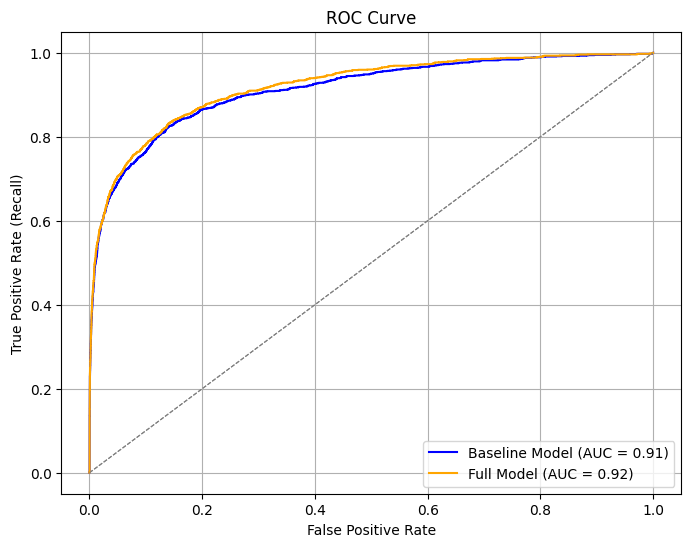

In [67]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

def plot_roc_auc(y_true, y_scores, label='Model', color='blue', ax=None):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))

    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC = {auc_score:.2f})')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=0.8)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')
    ax.set_title('ROC Curve')
    ax.grid(True)

    return auc_score, ax

fig, ax = plt.subplots(figsize=(8, 6))

auc_baseline, _ = plot_roc_auc(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model',
    color='blue',
    ax=ax
)

auc_full, _ = plot_roc_auc(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model',
    color='orange',
    ax=ax
)

ax.legend()
plt.show()


#### Dataset is imbalanced, so we need to visualize the model to find the best threshold to prioritize recall (detect ICU deaths), but still care about precision (avoid false alarms).


| Term          | What it is                                                   | What it tells you                                                     |
|---------------|--------------------------------------------------------------|------------------------------------------------------------------------|
| **ROC Curve** | A **graph** showing model performance at all thresholds      | Visual: how well the model separates positive and negative classes     |
| **AUC-ROC**   | A **number** between 0 and 1 summarizing the ROC curve       | Score: how well the model ranks positive over negative                 |
| **PR Curve**  | A **graph** of precision vs recall across thresholds         | Helps you **choose a threshold** by optimizing metrics like F1         |  



PR curve for choosing optimal threshold (select the threshold that yields the highest F1)


Baseline Model (No Sens)
Best threshold based on F1 score: 0.325
Precision: 0.719, Recall: 0.590, F1: 0.648

Full Model (With Sens)
Best threshold based on F1 score: 0.356
Precision: 0.743, Recall: 0.579, F1: 0.651


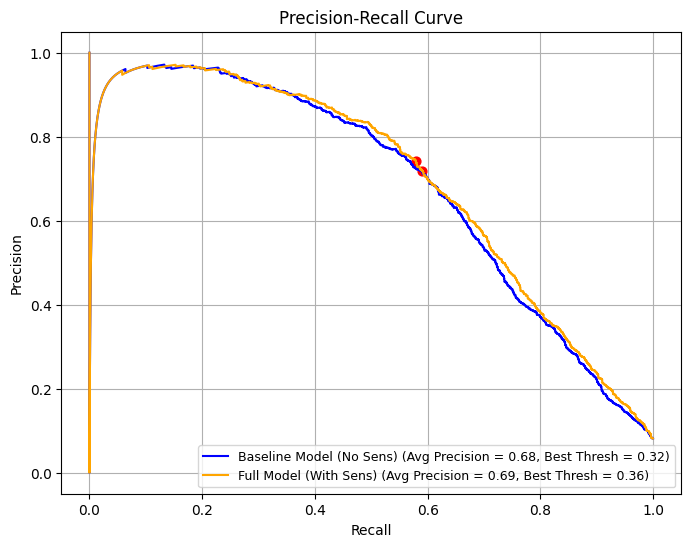

In [316]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

def plot_pr_and_find_best_threshold(y_true, y_scores, label='Model', color='black', ax=None):
    precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)
    ap_score = average_precision_score(y_true, y_scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    ax.plot(recall, precision, color=color, label=f'{label} (Avg Precision = {ap_score:.2f}, Best Thresh = {best_threshold:.2f})')
    ax.scatter(recall[best_idx], precision[best_idx], color='red', s=40)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.grid(True)

    print(f"\n{label}")
    print(f"Best threshold based on F1 score: {best_threshold:.3f}")
    print(f"Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}, F1: {best_f1:.3f}")

    y_pred = (y_scores >= best_threshold).astype(int)
    return best_threshold, y_pred, auc_score, best_f1, ax

fig, ax = plt.subplots(figsize=(8, 6))

best_thresh_baseline, y_pred_baseline, auc_baseline, best_f1_baseline, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model (No Sens)',
    color='blue',
    ax=ax
)

best_thresh_full, y_pred_full, auc_full, best_f1_full, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model (With Sens)',
    color='orange',
    ax=ax
)


ax.legend(fontsize=9)
plt.show()


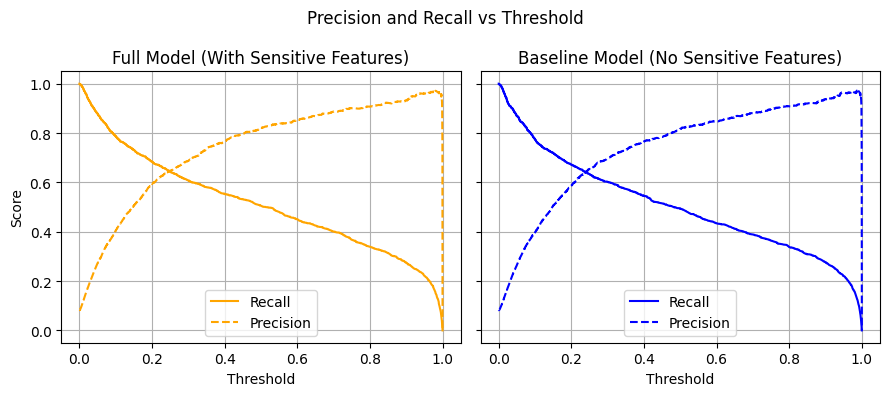

In [76]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision_full, recall_full, thresh_full = precision_recall_curve(y_test_baseline, y_proba_full)
precision_baseline, recall_baseline, thresh_baseline = precision_recall_curve(y_test_baseline, y_proba_baseline)


fig, axs = plt.subplots(1, 2, figsize=(9, 4), sharey=True)


axs[0].plot(thresh_full, recall_full[:-1], label='Recall', color='orange', linestyle='-')
axs[0].plot(thresh_full, precision_full[:-1], label='Precision', color='orange', linestyle='--')
axs[0].set_title('Full Model (With Sensitive Features)')
axs[0].set_xlabel('Threshold')
axs[0].set_ylabel('Score')
axs[0].legend()
axs[0].grid(True)


axs[1].plot(thresh_baseline, recall_baseline[:-1], label='Recall', color='blue', linestyle='-')
axs[1].plot(thresh_baseline, precision_baseline[:-1], label='Precision', color='blue', linestyle='--')
axs[1].set_title('Baseline Model (No Sensitive Features)')
axs[1].set_xlabel('Threshold')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Precision and Recall vs Threshold')
plt.tight_layout()
plt.show()


#### Finalize the Full model and Baseline model
- Find the optimal threshold that gives the best F1 score

Baseline Model (No Sensitive Features)
              precision    recall  f1-score   support

           0      0.964     0.979     0.972     17339
           1      0.719     0.590     0.648      1550

    accuracy                          0.947     18889
   macro avg      0.841     0.785     0.810     18889
weighted avg      0.944     0.947     0.945     18889


AUC: 0.912

Full Model (With Sensitive Features)
              precision    recall  f1-score   support

           0      0.963     0.982     0.973     17339
           1      0.743     0.579     0.651      1550

    accuracy                          0.949     18889
   macro avg      0.853     0.781     0.812     18889
weighted avg      0.945     0.949     0.946     18889

AUC: 0.920


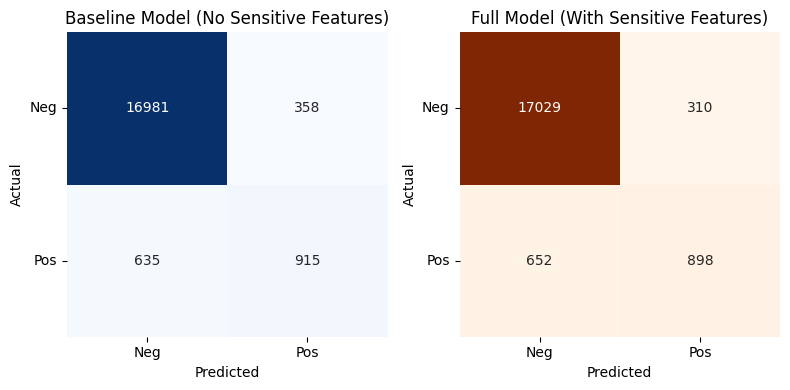

In [136]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Baseline Model (No Sensitive Features)")
print(classification_report(y_test_baseline, y_pred_baseline, digits=3))
print(f"\nAUC: {auc_baseline:.3f}")

print("\nFull Model (With Sensitive Features)")
print(classification_report(y_test_full, y_pred_full, digits=3))
print(f"AUC: {auc_full:.3f}")


cm_baseline = confusion_matrix(y_test_baseline, y_pred_baseline)
cm_full = confusion_matrix(y_test_full, y_pred_full)


fig, axs = plt.subplots(1, 2, figsize=(8, 4))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[0])
axs[0].set_title('Baseline Model (No Sensitive Features)')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].set_xticklabels(['Neg', 'Pos'])
axs[0].set_yticklabels(['Neg', 'Pos'], rotation=0)


sns.heatmap(cm_full, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axs[1])
axs[1].set_title('Full Model (With Sensitive Features)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].set_xticklabels(['Neg', 'Pos'])
axs[1].set_yticklabels(['Neg', 'Pos'], rotation=0)

plt.tight_layout()
plt.show()


### Fairness Diagnosis

Reference:  
https://afraenkel.github.io/fairness-book/content/05-parity-measures.html  
- Equal Opportunity – TPR (Recall)
- Statistical Parity – PPR
- Equalized Odds – TPR, FPR
- Calibration – Predicted probabilities

| **Fairness Metric**      | **What It Measures**                                              | **Key Components**                  |
|--------------------------|-------------------------------------------------------------------|-------------------------------------|
| **Equal Opportunity**    | Equal ability to correctly identify positive cases               | **TPR (Recall)**                    |
| **Statistical Parity**   | Equal likelihood of receiving a positive prediction              | **PPR (Positive Prediction Rate)**  |
| **Equalized Odds**       | Equal error rates across groups                                  | **TPR** and **FPR**                 |
| **Calibration**          | Predicted probabilities reflect actual outcomes per group        | P(Y=1 \| P^=p,A=a)≈p                |

In [340]:
from sklearn.metrics import classification_report, confusion_matrix

def create_df_test(df, X_test, y_true, y_pred, y_score):
    df_test = df.loc[X_test.index].copy()
    df_test['y_true'] = y_true
    df_test['y_pred'] = y_pred
    df_test['y_score'] = y_score

    gender_map = {1: 'Male', 0: 'Female'}
    age_cols = ['age_18-29', 'age_30-49', 'age_50-64', 'age_65-79', 'age_80-91']
    race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
                'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']
    
    df_test['gender_group'] = df_test['gender'].map(gender_map)
    df_test['age_group'] = df_test[age_cols].idxmax(axis=1).str.replace('age_', '')
    df_test['race_group'] = df_test[race_cols].idxmax(axis=1).str.replace('race_', '')

    return df_test

df_test_full = create_df_test(df, X_test_full, y_test_full, y_pred_full, y_proba_full)
df_test_baseline = create_df_test(df, X_test_baseline, y_test_baseline, y_pred_baseline, y_proba_baseline)


def get_group_metrics(df_subset, group_col):
    metrics_list = []
    for group in df_subset[group_col].unique():
        group_df = df_subset[df_subset[group_col] == group]
        report = classification_report(
            group_df['y_true'], group_df['y_pred'],
            output_dict=True, zero_division=0
        )
        tn, fp, fn, tp = confusion_matrix(group_df['y_true'], group_df['y_pred']).ravel()
        metrics_list.append({
            'group': group,
            'support': report['1']['support'],
            'precision': report['1']['precision'],
            'recall (TPR)': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
            'PPR': group_df['y_pred'].mean()
        })
    return pd.DataFrame(metrics_list)

gender_report_full = get_group_metrics(df_test_full, 'gender_group')
age_report_full = get_group_metrics(df_test_full, 'age_group')
race_report_full = get_group_metrics(df_test_full, 'race_group')

gender_report_baseline = get_group_metrics(df_test_baseline, 'gender_group')
age_report_baseline = get_group_metrics(df_test_baseline, 'age_group')
race_report_baseline = get_group_metrics(df_test_baseline, 'race_group')

In [341]:
gender_report_full
age_report_full
race_report_full

,group,support,precision,recall (TPR),f1_score,FPR,PPR
0,WHITE,867.0,0.763608,0.566321,0.650331,0.013879,0.054404
1,OTHER,61.0,0.773585,0.672131,0.719298,0.015852,0.064792
2,UNKNOWN,329.0,0.742647,0.613982,0.672213,0.037076,0.122688
3,BLACK,141.0,0.666667,0.553191,0.604651,0.020051,0.056088
4,HISPANIC/LATINO,52.0,0.767442,0.634615,0.694737,0.015798,0.062774
5,ASIAN,53.0,0.761905,0.603774,0.673684,0.019342,0.073684
6,EUROPEAN,29.0,0.478261,0.379310,0.423077,0.024691,0.044660
7,RUSSIAN,18.0,0.666667,0.555556,0.606061,0.031056,0.083799


In [342]:
gender_report_baseline
age_report_baseline
race_report_baseline

,group,support,precision,recall (TPR),f1_score,FPR,PPR
0,WHITE,867.0,0.716667,0.595156,0.650284,0.018627,0.060919
1,OTHER,61.0,0.736842,0.688525,0.711864,0.019815,0.069682
2,UNKNOWN,329.0,0.816964,0.556231,0.661844,0.021716,0.101037
3,BLACK,141.0,0.602941,0.581560,0.592058,0.027763,0.065197
4,HISPANIC/LATINO,52.0,0.708333,0.653846,0.680000,0.022117,0.070073
5,ASIAN,53.0,0.772727,0.641509,0.701031,0.019342,0.077193
6,EUROPEAN,29.0,0.481481,0.448276,0.464286,0.028807,0.052427
7,RUSSIAN,18.0,0.647059,0.611111,0.628571,0.037267,0.094972


In [343]:
gender_report_full['model'] = 'Full'
age_report_full['model'] = 'Full'
race_report_full['model'] = 'Full'

gender_report_baseline['model'] = 'Baseline'
age_report_baseline['model'] = 'Baseline'
race_report_baseline['model'] = 'Baseline'

gender_comparison = pd.concat([gender_report_full, gender_report_baseline])
age_comparison = pd.concat([age_report_full, age_report_baseline])
race_comparison = pd.concat([race_report_full, race_report_baseline])

gender_comparison
age_comparison
race_comparison

,group,support,precision,recall (TPR),f1_score,FPR,PPR,model
0,WHITE,867.0,0.763608,0.566321,0.650331,0.013879,0.054404,Full
1,OTHER,61.0,0.773585,0.672131,0.719298,0.015852,0.064792,Full
2,UNKNOWN,329.0,0.742647,0.613982,0.672213,0.037076,0.122688,Full
3,BLACK,141.0,0.666667,0.553191,0.604651,0.020051,0.056088,Full
4,HISPANIC/LATINO,52.0,0.767442,0.634615,0.694737,0.015798,0.062774,Full
5,ASIAN,53.0,0.761905,0.603774,0.673684,0.019342,0.073684,Full
6,EUROPEAN,29.0,0.478261,0.379310,0.423077,0.024691,0.044660,Full
7,RUSSIAN,18.0,0.666667,0.555556,0.606061,0.031056,0.083799,Full
0,WHITE,867.0,0.716667,0.595156,0.650284,0.018627,0.060919,Baseline
1,OTHER,61.0,0.736842,0.688525,0.711864,0.019815,0.069682,Baseline


#### Equal Opportunity
All groups should have equal TPR (recall).

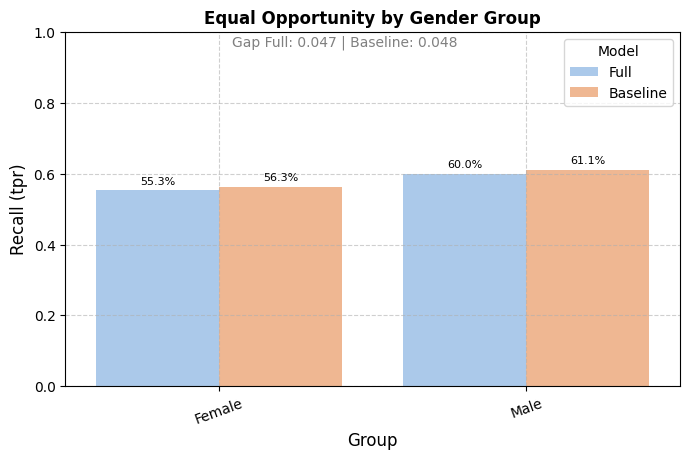

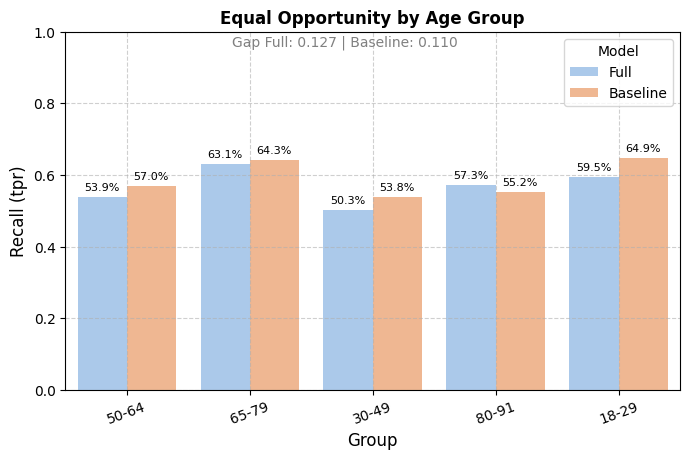

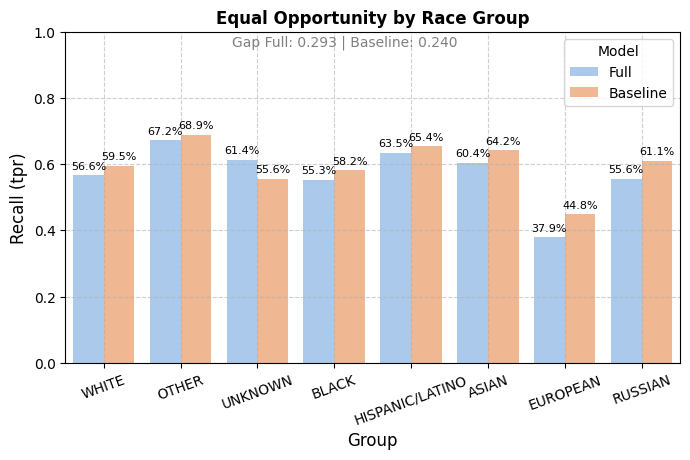

In [344]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_group_comparison_with_gap(df, metric='recall (TPR)', title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_dict = {}
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df[metric].max() - group_df[metric].min()
        gap_dict[model] = gap
    
    subtitle = "Gap " + " | ".join([f"{model}: {gap:.3f}" for model, gap in gap_dict.items()])

    
    ax = sns.barplot(data=df, x='group', y=metric, hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel(metric.capitalize(), fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=8, color='black')

    plt.tight_layout()
    plt.show()

    return gap_dict


eo_gender_gap = plot_group_comparison_with_gap(gender_comparison, metric='recall (TPR)', title='Equal Opportunity by Gender Group')
eo_age_gap = plot_group_comparison_with_gap(age_comparison, metric='recall (TPR)', title='Equal Opportunity by Age Group')
eo_race_gap = plot_group_comparison_with_gap(race_comparison, metric='recall (TPR)', title='Equal Opportunity by Race Group')


#### Positive Prediction Rate by Group (Statistical Parity)

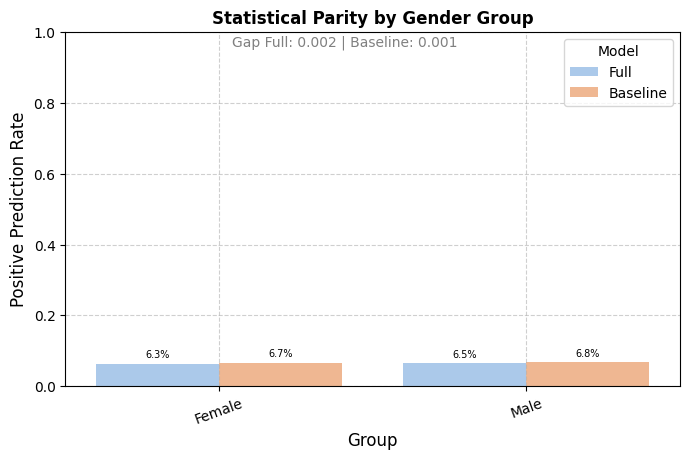

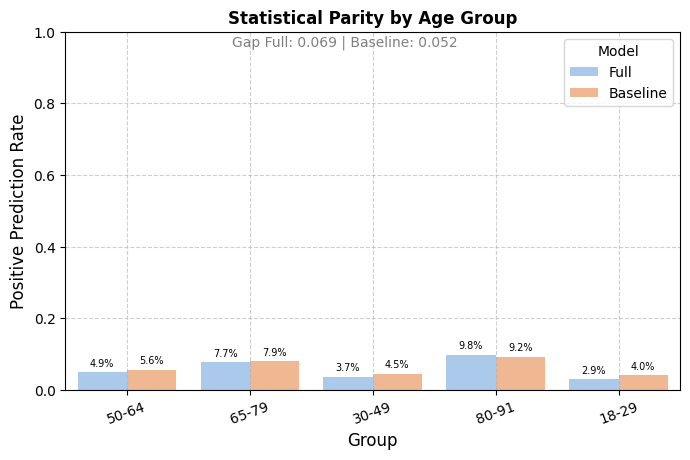

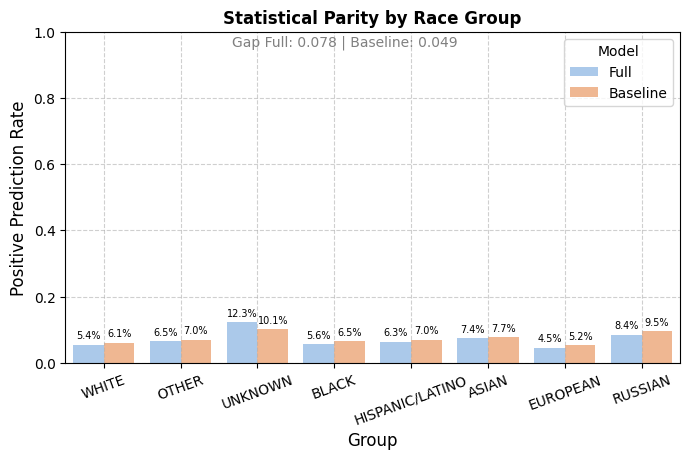

In [345]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_statistical_parity(df, title='', figsize=(7, 5)):
    plt.figure(figsize=figsize)
    
    # subtitle
    gap_texts = []
    for model in df['model'].unique():
        group_df = df[df['model'] == model]
        gap = group_df['PPR'].max() - group_df['PPR'].min()
        gap_texts.append(f"{model}: {gap:.3f}")
    subtitle = "Gap " + " | ".join(gap_texts)


    ax = sns.barplot(data=df, x='group', y='PPR', hue='model', palette='pastel')
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    plt.suptitle(subtitle, fontsize=10, y=0.86, color='gray')

    ax.set_ylabel('Positive Prediction Rate', fontsize=12)
    ax.set_xlabel('Group', fontsize=12)
    plt.xticks(rotation=20)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(title='Model')

    # Annotate each bar
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.1%}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords='offset points',
                            ha='center', va='bottom',
                            fontsize=7, color='black')

    plt.tight_layout()
    plt.show()

plot_statistical_parity(df=gender_comparison, title='Statistical Parity by Gender Group')
plot_statistical_parity(df=age_comparison, title='Statistical Parity by Age Group')
plot_statistical_parity(df=race_comparison, title='Statistical Parity by Race Group')


#### Equaliezed Odds - TPR, FPR

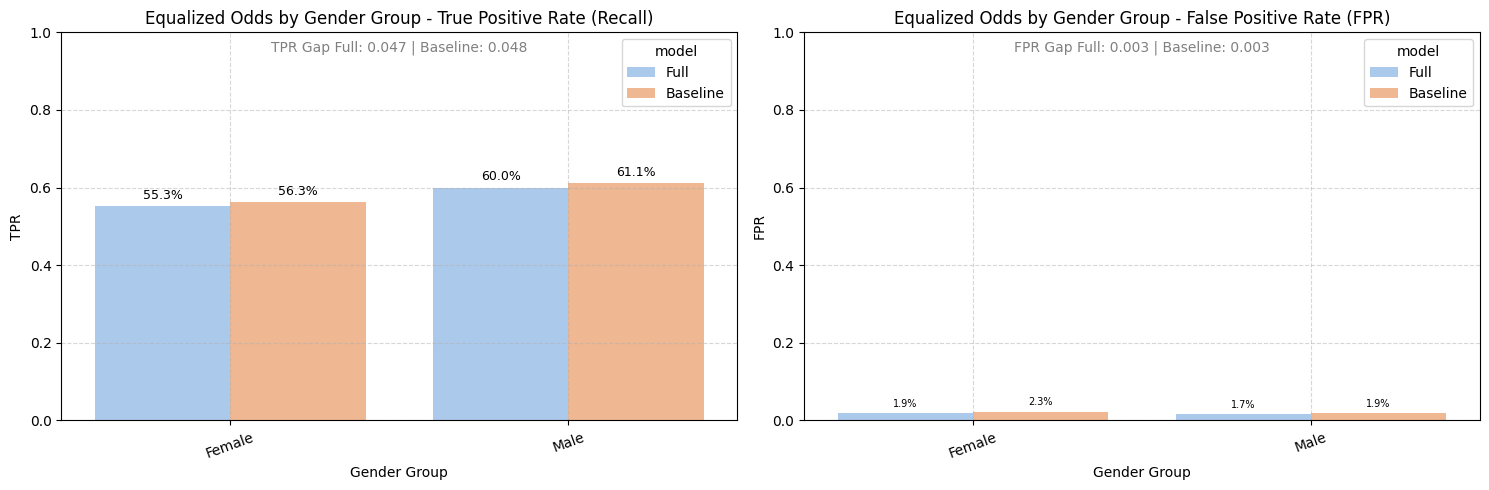

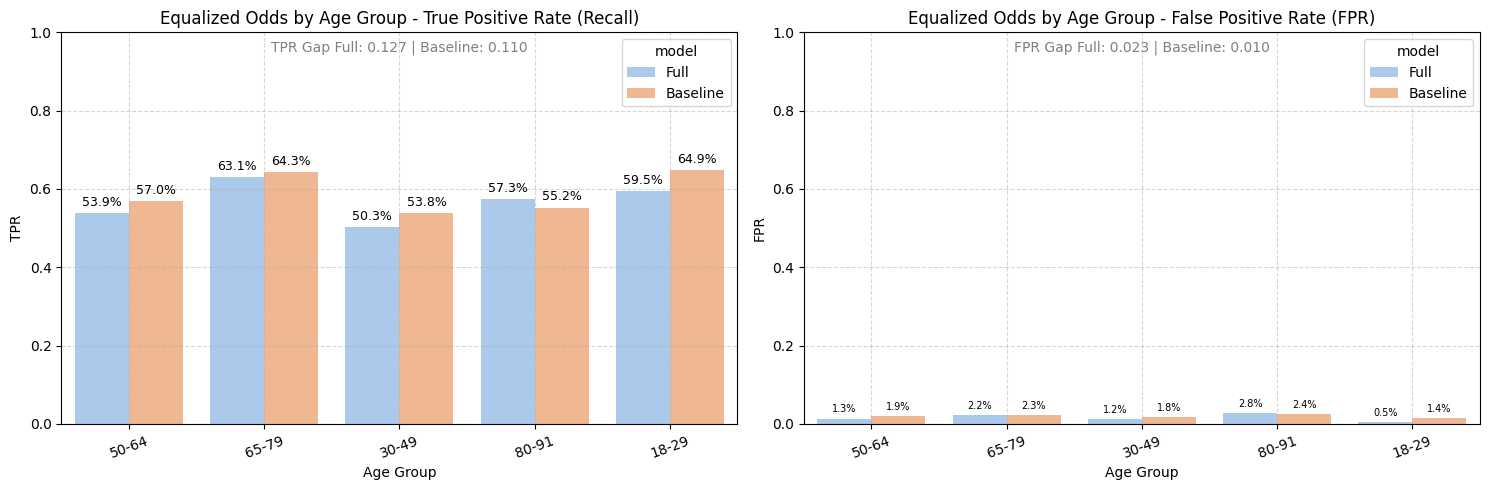

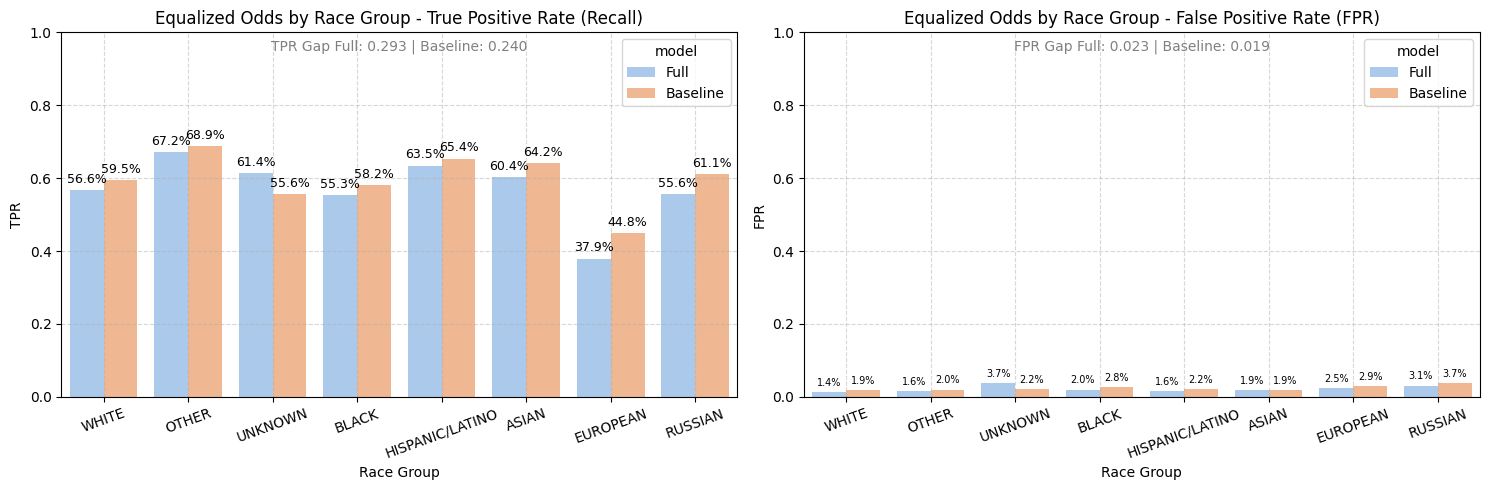

In [346]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_equalized_odds(df, group_col_name, title_prefix, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 2, figsize=figsize, sharey=False)

    # subtitles
    tpr_gap_texts = []
    fpr_gap_texts = []

    for model in df['model'].unique():
        model_df = df[df['model'] == model]
        tpr_gap = model_df['recall (TPR)'].max() - model_df['recall (TPR)'].min()
        fpr_gap = model_df['FPR'].max() - model_df['FPR'].min()
        tpr_gap_texts.append(f"{model}: {tpr_gap:.3f}")
        fpr_gap_texts.append(f"{model}: {fpr_gap:.3f}")

    axs[0].text(0.5, 0.95, "TPR Gap " + " | ".join(tpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[0].transAxes)

    axs[1].text(0.5, 0.95, "FPR Gap " + " | ".join(fpr_gap_texts),
                fontsize=10, color='gray', ha='center', transform=axs[1].transAxes)


    # TPR
    sns.barplot(data=df, x='group', y='recall (TPR)', hue='model', palette='pastel', ax=axs[0])
    axs[0].set_title(f'{title_prefix} - True Positive Rate (Recall)', fontsize=12)
    axs[0].set_xlabel(group_col_name)
    axs[0].tick_params(axis='x', rotation=20)
    axs[0].set_ylabel('TPR')
    axs[0].set_ylim(0, 1)
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[0].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[0].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=9)

    # FPR
    sns.barplot(data=df, x='group', y='FPR', hue='model', palette='pastel', ax=axs[1])
    axs[1].set_title(f'{title_prefix} - False Positive Rate (FPR)', fontsize=12)
    axs[1].set_xlabel(group_col_name)
    axs[1].tick_params(axis='x', rotation=20)
    axs[1].set_ylabel('FPR')
    axs[1].set_ylim(0, 1)
    axs[1].grid(True, linestyle='--', alpha=0.5)

    # Annotate the bar
    for container in axs[1].containers:
        for bar in container:
            height = bar.get_height()
            if not np.isnan(height):
                axs[1].annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width() / 2, height),
                                xytext=(0, 3), textcoords='offset points',
                                ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.show()

plot_equalized_odds(gender_comparison, group_col_name='Gender Group', title_prefix='Equalized Odds by Gender Group')
plot_equalized_odds(age_comparison, group_col_name='Age Group', title_prefix='Equalized Odds by Age Group')
plot_equalized_odds(race_comparison, group_col_name='Race Group', title_prefix='Equalized Odds by Race Group')

#### Calibration - The predicted probability reflects reality
x-axis	Mean predicted probability in each bin → average of y_score  
y-axis	Actual observed frequency → proportion of y_true == 1 in the bin  

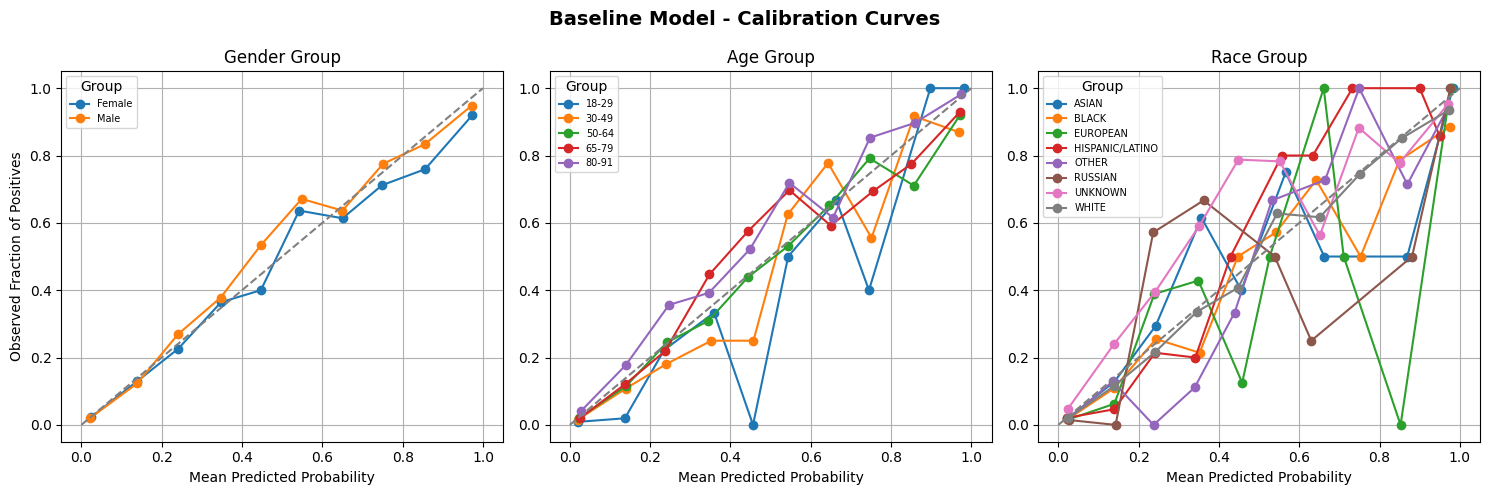

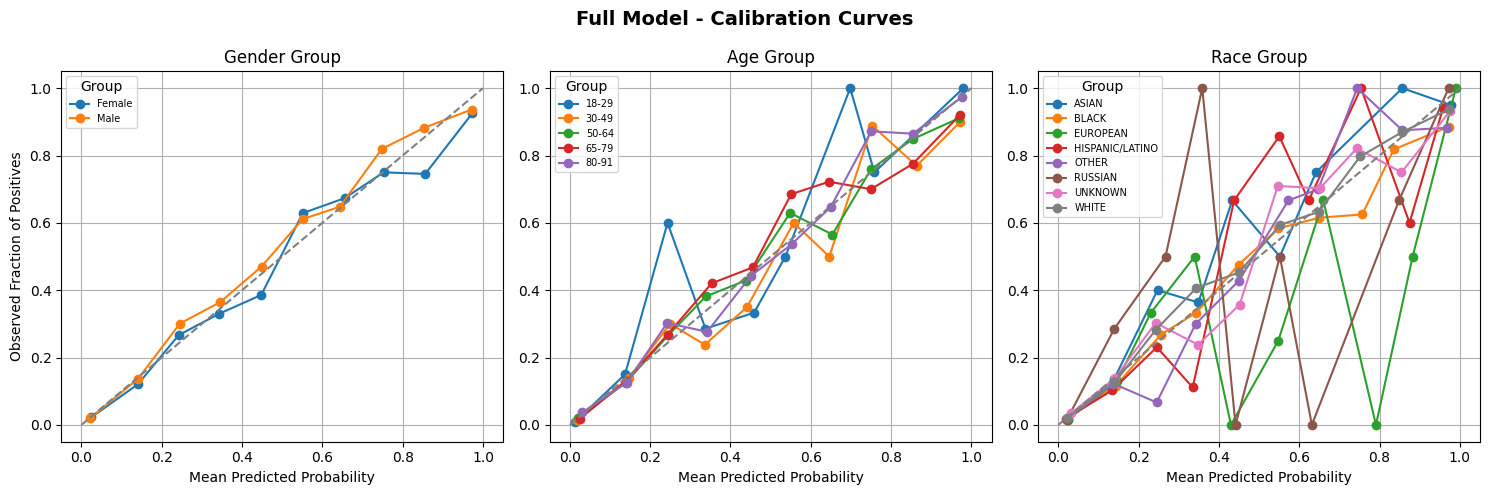

In [347]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

def plot_calibration_comparison_row(df, model_label, n_bins=10, figsize=(15, 5)):
    fig, axs = plt.subplots(1, 3, figsize=figsize)

    group_cols = ['gender_group', 'age_group', 'race_group']
    titles = ['Gender Group', 'Age Group', 'Race Group']

    for i, (group_col, title) in enumerate(zip(group_cols, titles)):
        groups = sorted(df[group_col].dropna().unique())
        ax = axs[i]

        for group in groups:
            group_df = df[df[group_col] == group]
            if len(group_df) == 0:
                continue
            y_true = group_df['y_true']
            y_score = group_df['y_score']
            if y_true.sum() > 0:
                prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins, strategy='uniform')
                ax.plot(prob_pred, prob_true, marker='o', label=group)

        ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
        ax.set_xlabel('Mean Predicted Probability')
        if i == 0:
            ax.set_ylabel('Observed Fraction of Positives')
        ax.set_title(f'{title}')
        ax.grid(True)
        ax.legend(fontsize=7, title='Group')

    plt.suptitle(f'{model_label} Model - Calibration Curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

df_list = [df_test_baseline, df_test_full]
model_labels = ['Baseline', 'Full']

for df, label in zip(df_list, model_labels):
    plot_calibration_comparison_row(df, label)


#### Bias Mitigation 1
- apply SMOTE (Synthetic Minority Over-sampling Technique) to address class imbalance in the ICU mortality label  
- reweighting  

In [214]:
df_dummy = df.copy()

age_cols = ['age_18-29', 'age_30-49', 'age_50-64', 'age_65-79', 'age_80-91']
race_cols = ['race_ASIAN', 'race_BLACK', 'race_EUROPEAN', 'race_HISPANIC/LATINO',
             'race_OTHER', 'race_RUSSIAN', 'race_UNKNOWN', 'race_WHITE']

df_dummy['age_group'] = df_dummy[age_cols].idxmax(axis=1).str.replace('age_', '')
df_dummy['race_group'] = df_dummy[race_cols].idxmax(axis=1).str.replace('race_', '')
df_dummy['gender_group'] = df_dummy['gender'].map({0: 'Female', 1: 'Male'})

# reweighting intersection group (gender, age, race)
df_dummy['intersection_group'] = df_dummy[['gender', 'race_group', 'age_group']].astype(str).agg('-'.join, axis=1)
group_counts = df_dummy['intersection_group'].value_counts()
group_weights = 1 / group_counts
group_weights = group_weights / group_weights.sum()
df_dummy['group_weight'] = df_dummy['intersection_group'].map(group_weights)
df_dummy

,los,gender,age_18-29,age_30-49,age_50-64,age_65-79,age_80-91,race_ASIAN,race_BLACK,race_EUROPEAN,...,lab_count_51006_missing,lab_count_51221_missing,lab_count_51222_missing,lab_count_51265_missing,icu_mortality,age_group,race_group,gender_group,intersection_group,group_weight
0,0.410266,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,1,1,1,0,50-64,WHITE,Female,0-WHITE-50-64,0.000088
1,3.893252,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,80-91,WHITE,Female,0-WHITE-80-91,0.000106
2,0.497535,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1,1,1,1,0,65-79,BLACK,Female,0-BLACK-65-79,0.000369
3,1.118032,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,50-64,WHITE,Female,0-WHITE-50-64,0.000088
4,0.948113,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,50-64,WHITE,Female,0-WHITE-50-64,0.000088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94439,6.950370,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,30-49,WHITE,Male,1-WHITE-30-49,0.000146
94440,0.960741,1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0,0,0,0,0,80-91,WHITE,Male,1-WHITE-80-91,0.000114
94441,1.790995,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,30-49,WHITE,Female,0-WHITE-30-49,0.000188
94442,5.297766,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,50-64,WHITE,Male,1-WHITE-50-64,0.000057


In [215]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

X = df.drop(columns=['icu_mortality'])
y = df['icu_mortality']
sample_weight = df_dummy['group_weight']

X_train_bm1, X_test_bm1, y_train_bm1, y_test_bm1, w_train_bm1, w_test_bm1 = train_test_split(X, y, sample_weight, test_size=0.2, stratify=y, random_state=35)

scaler = StandardScaler()
X_train_bm1_scaled = scaler.fit_transform(X_train_bm1)
X_test_bm1_scaled = scaler.transform(X_test_bm1)

# ----------------------------------------------- manually smote ----------------------------------------------
X_train_bm1_df = pd.DataFrame(X_train_bm1_scaled)
X_train_bm1_df['y'] = y_train_bm1.reset_index(drop=True)
X_train_bm1_df['weight'] = w_train_bm1.reset_index(drop=True)

pos = X_train_bm1_df[X_train_bm1_df['y'] == 1]
neg = X_train_bm1_df[X_train_bm1_df['y'] == 0]

# upsample, shuffle and combine
pos_upsampled = pos.sample(n=len(neg), replace=True, random_state=35)
smote = pd.concat([neg, pos_upsampled], axis=0).sample(frac=1, random_state=35).reset_index(drop=True)

X_train_bm1_smote = smote.drop(columns=['y', 'weight']).values
y_train_bm1_smote = smote['y'].values
w_train_bm1_smote = smote['weight'].values

lr = LogisticRegression(max_iter=1000, random_state=35)
lr.fit(X_train_bm1_smote, y_train_bm1_smote, sample_weight=w_train_bm1_smote)

y_pred_bm1 = lr.predict(X_test_bm1_scaled)
y_proba_bm1 = lr.predict_proba(X_test_bm1_scaled)[:, 1]

print("=== Bias Mitigation 1 - SMOTE + Reweighting ===")
print(classification_report(y_test_bm1, y_pred_bm1))
print("AUC:", roc_auc_score(y_test_bm1, y_proba_bm1))


=== Bias Mitigation 1 - SMOTE + Reweighting ===
              precision    recall  f1-score   support

           0       0.98      0.84      0.91     17339
           1       0.31      0.79      0.45      1550

    accuracy                           0.84     18889
   macro avg       0.64      0.82      0.68     18889
weighted avg       0.92      0.84      0.87     18889

AUC: 0.897650532363179


#### Bias Mitigation 2
- ExponentiatedGradient with regularization  

In [227]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
sens = df_dummy['race_group']

X_train_bm2, X_test_bm2, y_train_bm2, y_test_bm2, s_train_bm2, s_test_bm2 = train_test_split(
    X, y, sens, test_size=0.2, stratify=y, random_state=35
)

scaler = StandardScaler()
X_train_bm2_scaled = scaler.fit_transform(X_train_bm2)
X_test_bm2_scaled = scaler.transform(X_test_bm2)

# ----------------------------------------------- manually smote ----------------------------------------------
X_train_bm2_df = pd.DataFrame(X_train_bm2_scaled, columns=X.columns)
X_train_bm2_df['y'] = y_train_bm2.reset_index(drop=True)
X_train_bm2_df['race_group'] = s_train_bm2.reset_index(drop=True)

pos = X_train_bm2_df[X_train_bm2_df['y'] == 1]
neg = X_train_bm2_df[X_train_bm2_df['y'] == 0]

# upsample, shuffle and combine
pos_upsampled = pos.sample(n=len(neg), replace=True, random_state=35)
smote = pd.concat([neg, pos_upsampled], axis=0).sample(frac=1, random_state=35).reset_index(drop=True)

X_train_bm2_smote = smote.drop(columns=['y', 'race_group']).values
y_train_bm2_smote = smote['y'].values
s_train_bm2_smote = smote['race_group'].values

lr = LogisticRegression(max_iter=3000, random_state=35)
mitigator = ExponentiatedGradient(
    estimator=lr,
    constraints=EqualizedOdds()
)

mitigator.fit(X_train_bm2_smote, y_train_bm2_smote, sensitive_features=s_train_bm2_smote)

y_pred_bm2 = mitigator.predict(X_test_bm2_scaled)
y_proba_bm2 = mitigator._pmf_predict(X_test_bm2_scaled)[:, 1]

print("=== Bias Mitigation 2 - SMOTE + Regularization ===")
print(classification_report(y_test_bm2, y_pred_bm2))
print("AUC:", roc_auc_score(y_test_bm2, y_proba_bm2))

=== Bias Mitigation 2 - SMOTE + Regularization ===
              precision    recall  f1-score   support

           0       0.98      0.86      0.91     17339
           1       0.34      0.80      0.47      1550

    accuracy                           0.85     18889
   macro avg       0.66      0.83      0.69     18889
weighted avg       0.93      0.85      0.88     18889

AUC: 0.8762243981031015


#### Bias Mitigation 3  
Reference:  
https://fairlearn.org/v0.9/api_reference/generated/fairlearn.adversarial.AdversarialFairnessClassifier.html  
Notes:  
fairlearn.adversarial.AdversarialFairnessClassifier, it expects numpy arrays (no manual TensorFlow conversion needed).  

In [228]:
X = df.drop(columns='icu_mortality')
y = df['icu_mortality']
sens = df_dummy['race_group']

X_train_bm3, X_test_bm3, y_train_bm3, y_test_bm3, s_train_bm3, s_test_bm3 = train_test_split(
    X, y, sens, test_size=0.2, stratify=y, random_state=35
)

scaler = StandardScaler()
X_train_bm3_scaled = scaler.fit_transform(X_train_bm3)
X_test_bm3_scaled = scaler.transform(X_test_bm3)


# ----------------------------------------------- manually smote ----------------------------------------------
X_train_bm3_df = pd.DataFrame(X_train_bm3_scaled, columns=X.columns)
X_train_bm3_df['y'] = y_train_bm3.reset_index(drop=True)
X_train_bm3_df['race_group'] = s_train_bm3.reset_index(drop=True)

pos = X_train_bm3_df[X_train_bm3_df['y'] == 1]
neg = X_train_bm3_df[X_train_bm3_df['y'] == 0]

# upsample, shuffle and combine
pos_upsampled = pos.sample(n=len(neg), replace=True, random_state=35)
smote = pd.concat([neg, pos_upsampled], axis=0).sample(frac=1, random_state=35).reset_index(drop=True)

X_train_bm3_smote = smote.drop(columns=['y', 'race_group']).values
y_train_bm3_smote = smote['y'].values
s_train_bm3_smote = smote['race_group'].values

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
s_train_bm3_smote_encoded = le.fit_transform(s_train_bm3_smote)

encoding_map = {index: label for index, label in enumerate(le.classes_)}
print("Encoding Map:")
for k, v in encoding_map.items():
    print(f"{k} -> {v}")

print("\nTraining size and input features:")
print(X_train_bm3_smote.shape)



Encoding Map:
0 -> ASIAN
1 -> BLACK
2 -> EUROPEAN
3 -> HISPANIC/LATINO
4 -> OTHER
5 -> RUSSIAN
6 -> UNKNOWN
7 -> WHITE

Training size and input features:
(138706, 115)


Notes:  
Demographic Parity = adversary sees only prediction  
Equalized Odds / Equal Opportunity = adversary sees prediction + truth  

In [229]:
from fairlearn.adversarial import AdversarialFairnessClassifier
import tensorflow as tf

# --- One perceptron layer akin to Logistic Regression ---
input_dim = X_train_bm3_smote.shape[1]

predictor = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)), # Predictor input = 115 features
    tf.keras.layers.Dense(1, activation='sigmoid')  # logistic regression as 1 dense layer
])

adversary = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),  # Adversary input = predictor output = 1 probability
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='softmax')
])

afc = AdversarialFairnessClassifier(
    predictor_model=predictor,
    adversary_model=adversary,
    backend="tensorflow",
    constraints="equalized_odds",
    learning_rate=0.001,
    batch_size=256,
    epochs=20,
    shuffle=True,
    alpha=2.0,  # higher = more focus on fairness, lower = more focus on accuracy
)


afc.fit(
    X_train_bm3_smote,
    y_train_bm3_smote,
    sensitive_features=s_train_bm3_smote_encoded
)

y_pred_bm3 = afc.predict(X_test_bm3_scaled)
y_proba_bm3 = predictor.predict(X_test_bm3_scaled).flatten()

from sklearn.metrics import classification_report, roc_auc_score

print("\n=== Bias Mitigation3 - SMOTE + Adversarial ===")
print(classification_report(y_test_bm3, y_pred_bm3))
print("AUC:", roc_auc_score(y_test_bm3, y_proba_bm3))

591/591 [==============================] - 1s 731us/step

=== Bias Mitigation3 - SMOTE + Adversarial ===
              precision    recall  f1-score   support

           0       0.99      0.54      0.70     17339
           1       0.16      0.95      0.27      1550

    accuracy                           0.57     18889
   macro avg       0.57      0.75      0.48     18889
weighted avg       0.92      0.57      0.66     18889

AUC: 0.9142591658930361


####  Finalize Bias Mitigation Models
- Find the optimal threshold that gives the best F1 score

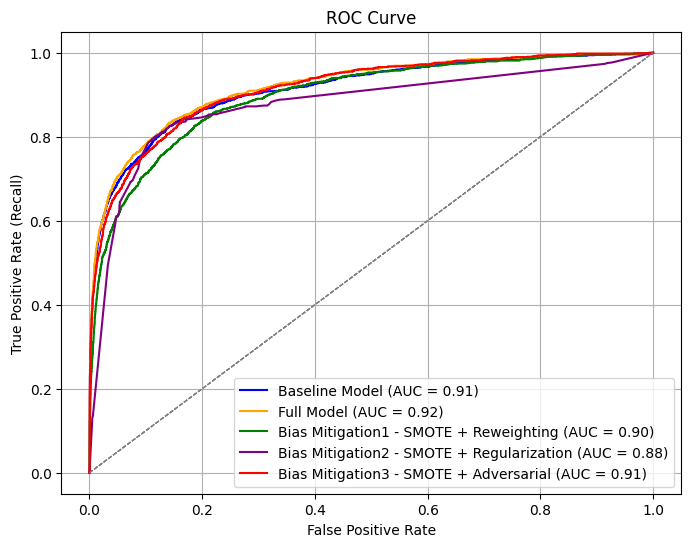

In [348]:
fig, ax = plt.subplots(figsize=(8, 6))

auc_baseline, _ = plot_roc_auc(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model',
    color='blue',
    ax=ax
)

auc_full, _ = plot_roc_auc(
    y_true=y_test_full,
    y_scores=y_proba_full,
    label='Full Model',
    color='orange',
    ax=ax
)

auc_bm1, _ = plot_roc_auc(
    y_true=y_test_bm1,
    y_scores=y_proba_bm1,
    label='Bias Mitigation1 - SMOTE + Reweighting',
    color='green',
    ax=ax
)

auc_bm2, _ = plot_roc_auc(
    y_true=y_test_bm2,
    y_scores=y_proba_bm2,
    label='Bias Mitigation2 - SMOTE + Regularization',
    color='purple',
    ax=ax
)

auc_bm3, _ = plot_roc_auc(
    y_true=y_test_bm3,
    y_scores=y_proba_bm3,
    label='Bias Mitigation3 - SMOTE + Adversarial',
    color='red',
    ax=ax
)

ax.legend()
plt.show()


Baseline Model (No Sensitive Features)
Best threshold based on F1 score: 0.325
Precision: 0.719, Recall: 0.590, F1: 0.648

Full Model (With Sensitive Features)
Best threshold based on F1 score: 0.356
Precision: 0.743, Recall: 0.579, F1: 0.651

Bias Mitigation1 - SMOTE + Reweighting
Best threshold based on F1 score: 0.821
Precision: 0.664, Recall: 0.515, F1: 0.580

Bias Mitigation2 - SMOTE + Regularization
Best threshold based on F1 score: 0.953
Precision: 0.517, Recall: 0.644, F1: 0.574

Bias Mitigation3 - SMOTE + Adversarial
Best threshold based on F1 score: 0.903
Precision: 0.668, Recall: 0.591, F1: 0.627


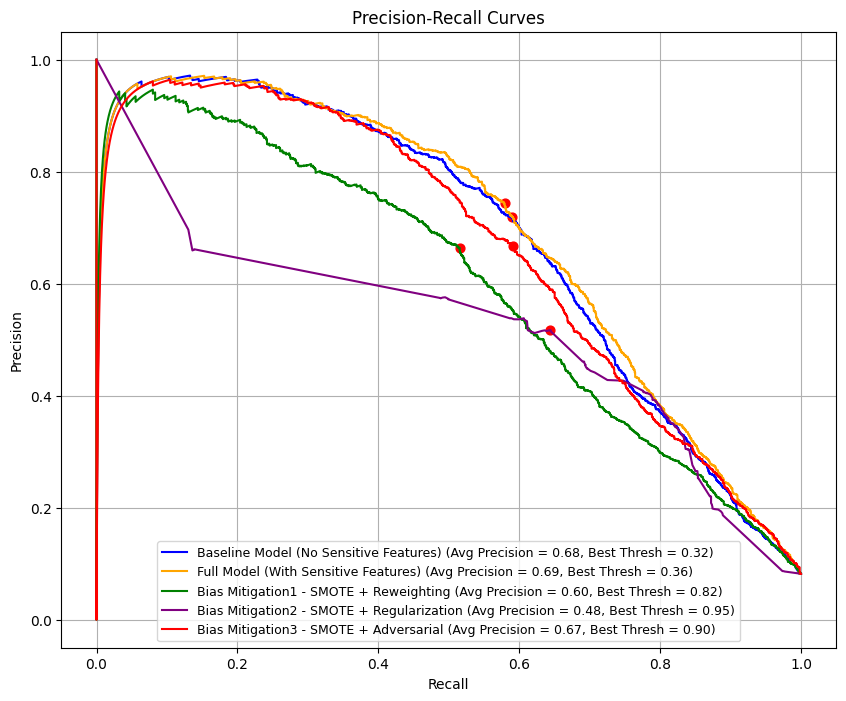

In [349]:
fig, ax = plt.subplots(figsize=(10, 8))


best_thresh_baseline, y_pred_baseline, auc_baseline, best_f1_baseline, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_baseline,
    y_scores=y_proba_baseline,
    label='Baseline Model (No Sensitive Features)',
    color='blue',
    ax=ax
)

best_thresh_full, y_pred_full, auc_full, best_f1_full, ax = plot_pr_and_find_best_threshold(
    y_true=y_test,
    y_scores=y_proba_full,
    label='Full Model (With Sensitive Features)',
    color='orange',
    ax=ax
)


best_thresh_bm1, y_pred_bm1, auc_bm1, best_f1_bm1, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm1,
    y_scores=y_proba_bm1,
    label='Bias Mitigation1 - SMOTE + Reweighting',
    color='green',
    ax=ax
)


best_thresh_bm2, y_pred_bm2, auc_bm2, best_f1_bm2, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm2,
    y_scores=y_proba_bm2,
    label='Bias Mitigation2 - SMOTE + Regularization',
    color='purple',
    ax=ax
)


best_thresh_bm3, y_pred_bm3, auc_bm3, best_f1_bm3, ax = plot_pr_and_find_best_threshold(
    y_true=y_test_bm3,
    y_scores=y_proba_bm3,
    label='Bias Mitigation3 - SMOTE + Adversarial',
    color='red',
    ax=ax
)


ax.legend(fontsize=9)
plt.title('Precision-Recall Curves')
plt.grid(True)
plt.show()


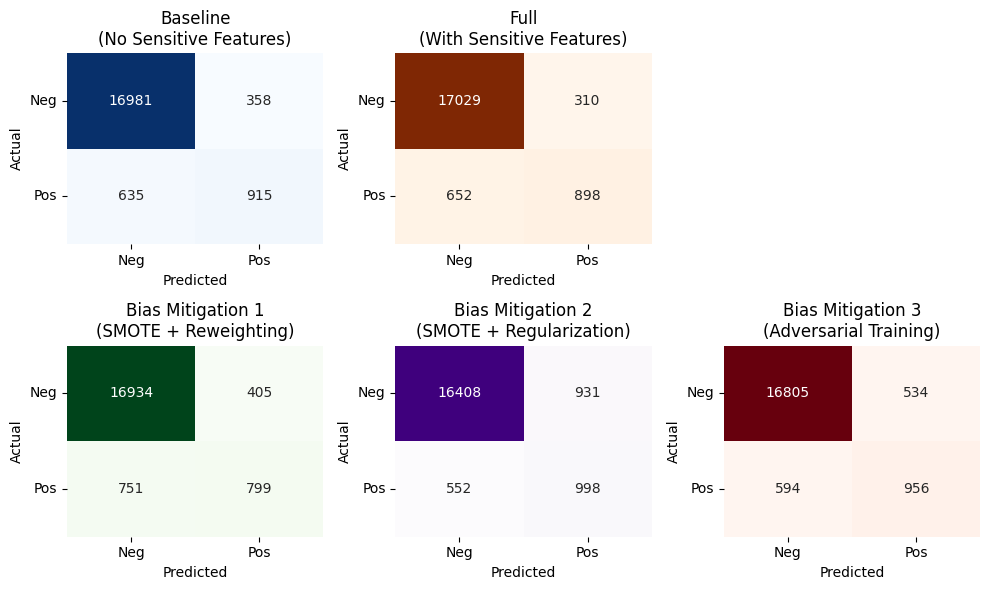

In [350]:
fig, axs = plt.subplots(2, 3, figsize=(10, 6))
axs = axs.flatten()

# Baseline
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axs[0])
axs[0].set_title('Baseline\n(No Sensitive Features)')
axs[0].set_xlabel('Predicted')
axs[0].set_ylabel('Actual')
axs[0].set_xticklabels(['Neg', 'Pos'])
axs[0].set_yticklabels(['Neg', 'Pos'], rotation=0)

# Full
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axs[1])
axs[1].set_title('Full\n(With Sensitive Features)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual')
axs[1].set_xticklabels(['Neg', 'Pos'])
axs[1].set_yticklabels(['Neg', 'Pos'], rotation=0)

axs[2].axis('off')

# BM1
sns.heatmap(cm_bm1, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axs[3])
axs[3].set_title('Bias Mitigation 1\n(SMOTE + Reweighting)')
axs[3].set_xlabel('Predicted')
axs[3].set_ylabel('Actual')
axs[3].set_xticklabels(['Neg', 'Pos'])
axs[3].set_yticklabels(['Neg', 'Pos'], rotation=0)

# BM2
sns.heatmap(cm_bm2, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axs[4])
axs[4].set_title('Bias Mitigation 2\n(SMOTE + Regularization)')
axs[4].set_xlabel('Predicted')
axs[4].set_ylabel('Actual')
axs[4].set_xticklabels(['Neg', 'Pos'])
axs[4].set_yticklabels(['Neg', 'Pos'], rotation=0)

# BM3
sns.heatmap(cm_bm3, annot=True, fmt='d', cmap='Reds', cbar=False, ax=axs[5])
axs[5].set_title('Bias Mitigation 3\n(Adversarial Training)')
axs[5].set_xlabel('Predicted')
axs[5].set_ylabel('Actual')
axs[5].set_xticklabels(['Neg', 'Pos'])
axs[5].set_yticklabels(['Neg', 'Pos'], rotation=0)

plt.tight_layout()
plt.show()


#### Fairness Diagnosis

In [351]:
from sklearn.metrics import classification_report, confusion_matrix

df_test_full = create_df_test(df, X_test_full, y_test_full, y_pred_full, y_proba_full)
df_test_baseline = create_df_test(df, X_test_baseline, y_test_baseline, y_pred_baseline, y_proba_baseline)
df_test_bm1 = create_df_test(df, X_test_bm1, y_test_bm1, y_pred_bm1, y_proba_bm1)
df_test_bm2 = create_df_test(df, X_test_bm2, y_test_bm2, y_pred_bm2, y_proba_bm2)
df_test_bm3 = create_df_test(df, X_test_bm3, y_test_bm3, y_pred_bm3, y_proba_bm3)

gender_report_full = get_group_metrics(df_test_full, 'gender_group')
age_report_full = get_group_metrics(df_test_full, 'age_group')
race_report_full = get_group_metrics(df_test_full, 'race_group')

gender_report_baseline = get_group_metrics(df_test_baseline, 'gender_group')
age_report_baseline = get_group_metrics(df_test_baseline, 'age_group')
race_report_baseline = get_group_metrics(df_test_baseline, 'race_group')

gender_report_bm1 = get_group_metrics(df_test_bm1, 'gender_group')
age_report_bm1 = get_group_metrics(df_test_bm1, 'age_group')
race_report_bm1 = get_group_metrics(df_test_bm1, 'race_group')

gender_report_bm2 = get_group_metrics(df_test_bm2, 'gender_group')
age_report_bm2 = get_group_metrics(df_test_bm2, 'age_group')
race_report_bm2 = get_group_metrics(df_test_bm2, 'race_group')

gender_report_bm3 = get_group_metrics(df_test_bm3, 'gender_group')
age_report_bm3 = get_group_metrics(df_test_bm3, 'age_group')
race_report_bm3 = get_group_metrics(df_test_bm3, 'race_group')


gender_report_full['model'] = 'Full'
age_report_full['model'] = 'Full'
race_report_full['model'] = 'Full'

gender_report_baseline['model'] = 'Baseline'
age_report_baseline['model'] = 'Baseline'
race_report_baseline['model'] = 'Baseline'

gender_report_bm1['model'] = 'bm1'
age_report_bm1['model'] = 'bm1'
race_report_bm1['model'] = 'bm1'

gender_report_bm2['model'] = 'bm2'
age_report_bm2['model'] = 'bm2'
race_report_bm2['model'] = 'bm2'

gender_report_bm3['model'] = 'bm3'
age_report_bm3['model'] = 'bm3'
race_report_bm3['model'] = 'bm3'

gender_comparison = pd.concat([gender_report_full, gender_report_baseline, gender_report_bm1, gender_report_bm2, gender_report_bm3])
age_comparison = pd.concat([age_report_full, age_report_baseline, age_report_bm1, age_report_bm2, age_report_bm3])
race_comparison = pd.concat([race_report_full, race_report_baseline, race_report_bm1, race_report_bm2, race_report_bm3])

gender_comparison
age_comparison
race_comparison

,group,support,precision,recall (TPR),f1_score,FPR,PPR,model
0,WHITE,867.0,0.763608,0.566321,0.650331,0.013879,0.054404,Full
1,OTHER,61.0,0.773585,0.672131,0.719298,0.015852,0.064792,Full
2,UNKNOWN,329.0,0.742647,0.613982,0.672213,0.037076,0.122688,Full
3,BLACK,141.0,0.666667,0.553191,0.604651,0.020051,0.056088,Full
4,HISPANIC/LATINO,52.0,0.767442,0.634615,0.694737,0.015798,0.062774,Full
5,ASIAN,53.0,0.761905,0.603774,0.673684,0.019342,0.073684,Full
6,EUROPEAN,29.0,0.478261,0.379310,0.423077,0.024691,0.044660,Full
7,RUSSIAN,18.0,0.666667,0.555556,0.606061,0.031056,0.083799,Full
0,WHITE,867.0,0.716667,0.595156,0.650284,0.018627,0.060919,Baseline
1,OTHER,61.0,0.736842,0.688525,0.711864,0.019815,0.069682,Baseline


#### Equal Opportunity  

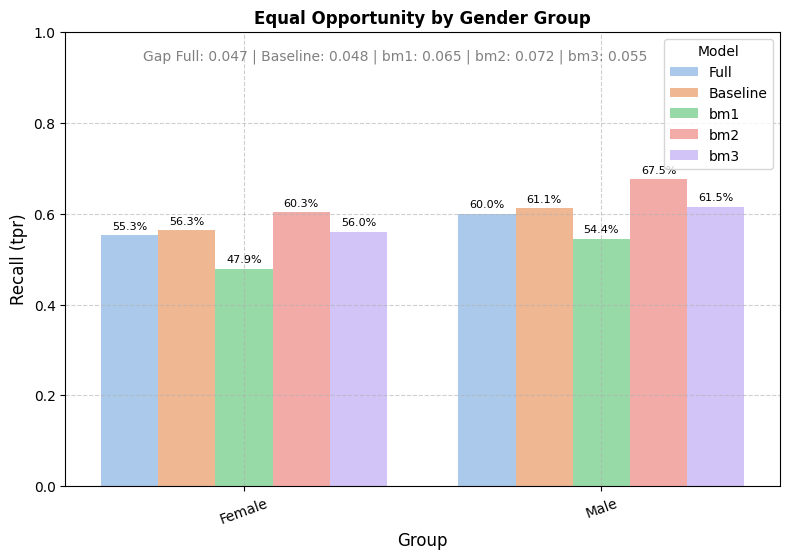

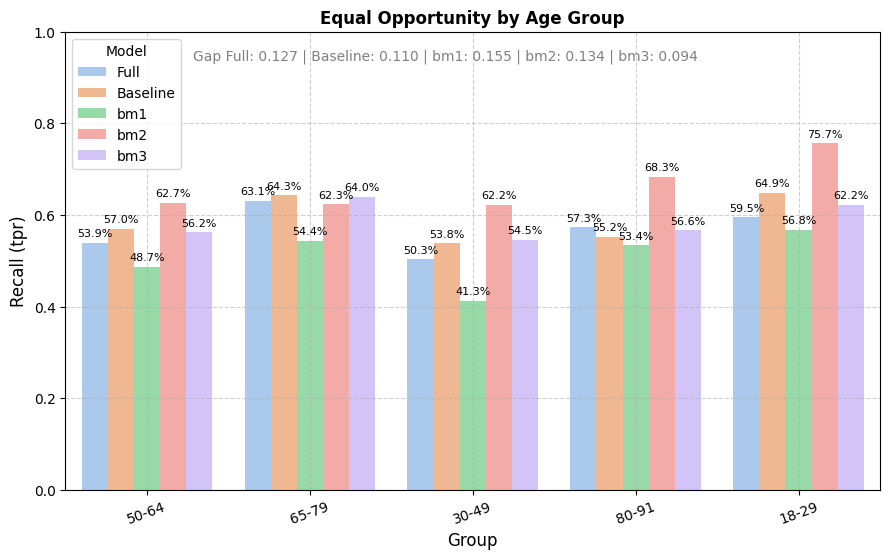

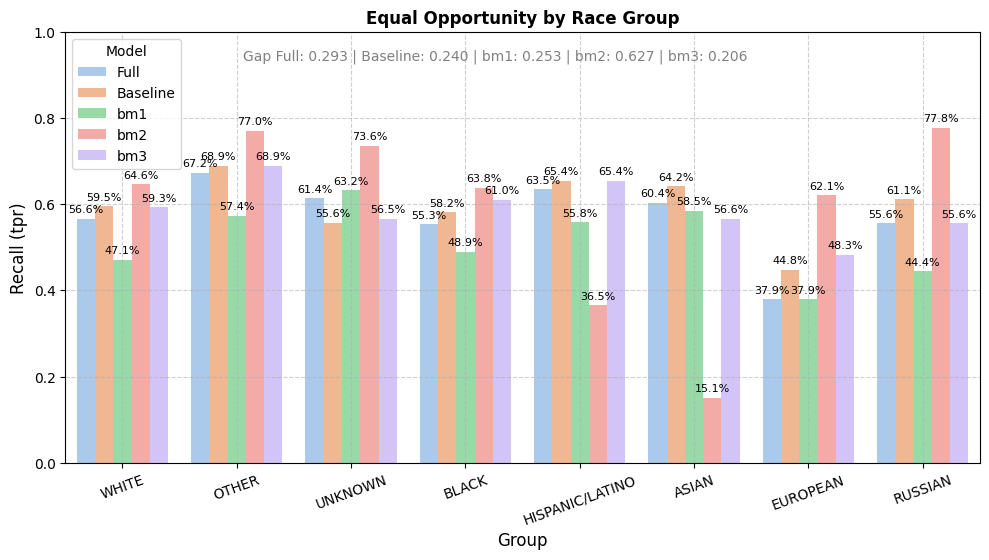

In [352]:
eo_gender_gap = plot_group_comparison_with_gap(gender_comparison, metric='recall (TPR)', title='Equal Opportunity by Gender Group', figsize=(8, 6))
eo_age_gap = plot_group_comparison_with_gap(age_comparison, metric='recall (TPR)', title='Equal Opportunity by Age Group', figsize=(9, 6))
eo_race_gap = plot_group_comparison_with_gap(race_comparison, metric='recall (TPR)', title='Equal Opportunity by Race Group', figsize=(10, 6))

#### Statistical Parity

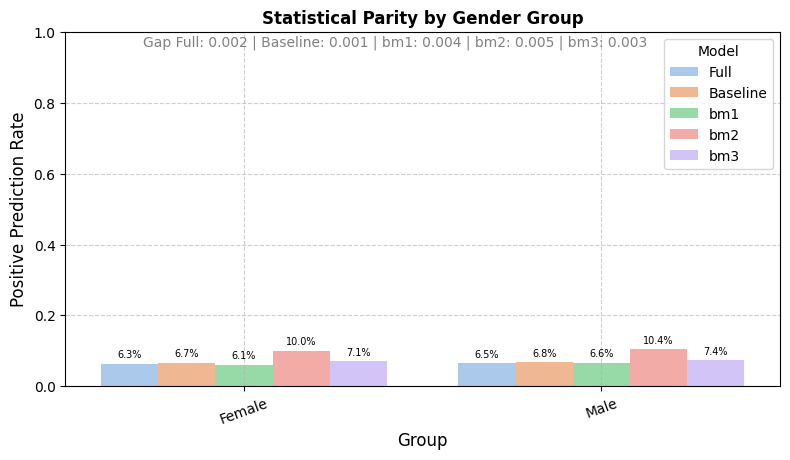

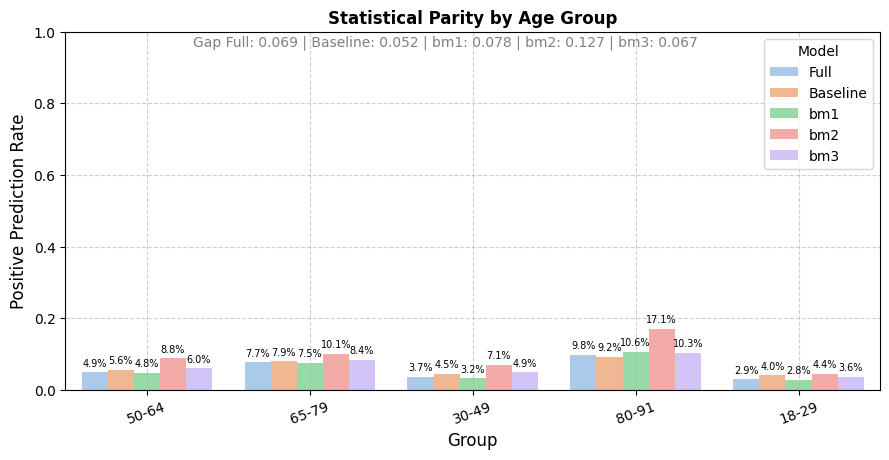

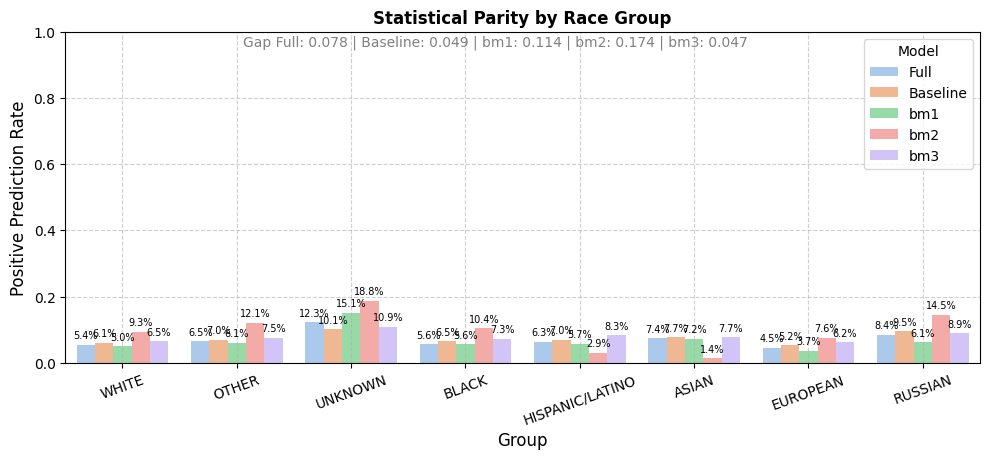

In [353]:
plot_statistical_parity(df=gender_comparison, title='Statistical Parity by Gender Group', figsize=(8, 5))
plot_statistical_parity(df=age_comparison, title='Statistical Parity by Age Group', figsize=(9, 5))
plot_statistical_parity(df=race_comparison, title='Statistical Parity by Race Group', figsize=(10, 5))

#### Equalized Odds

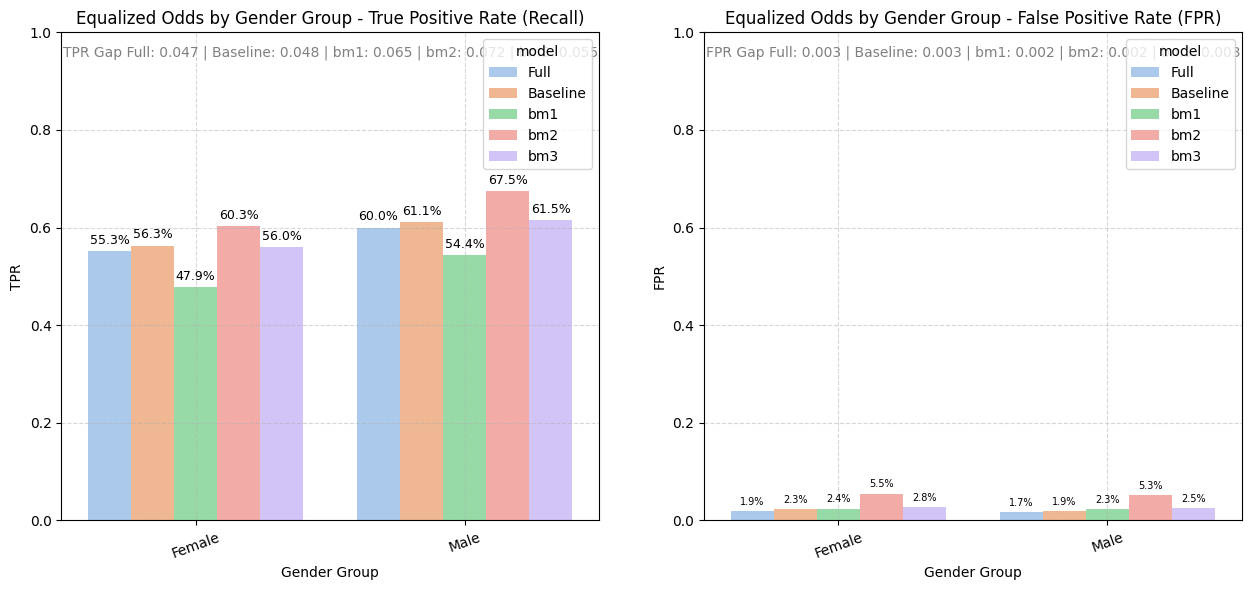

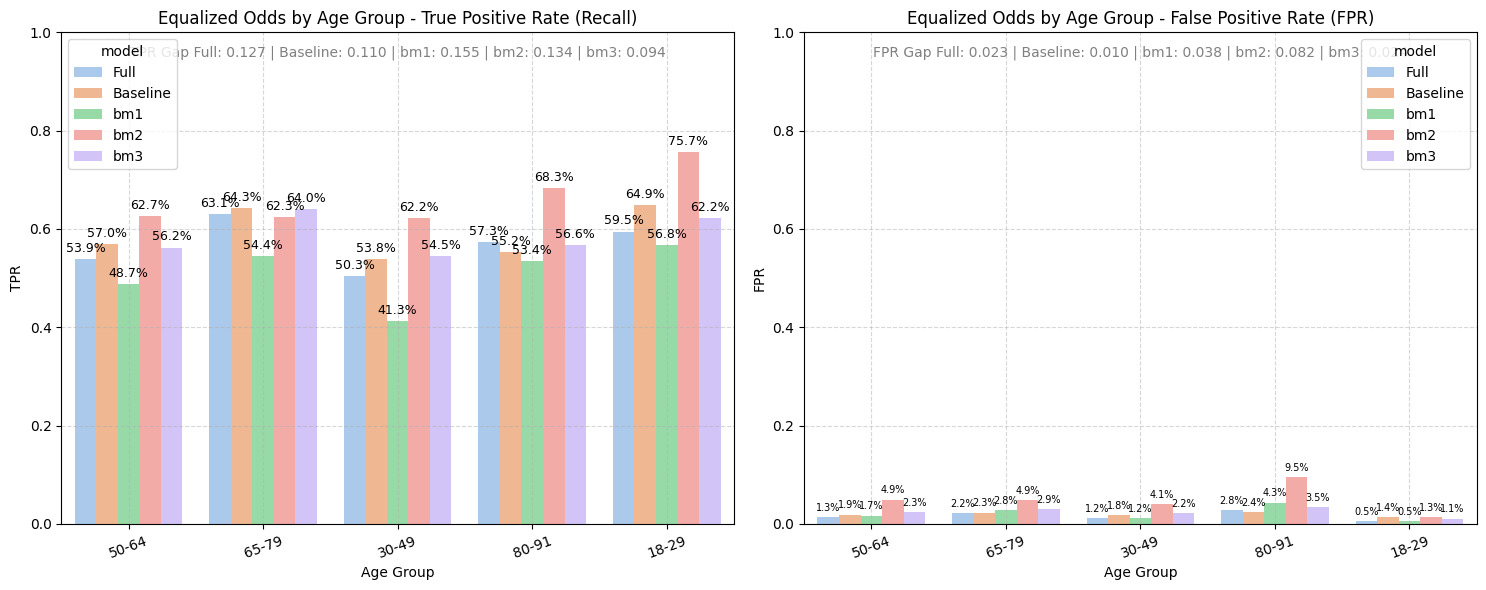

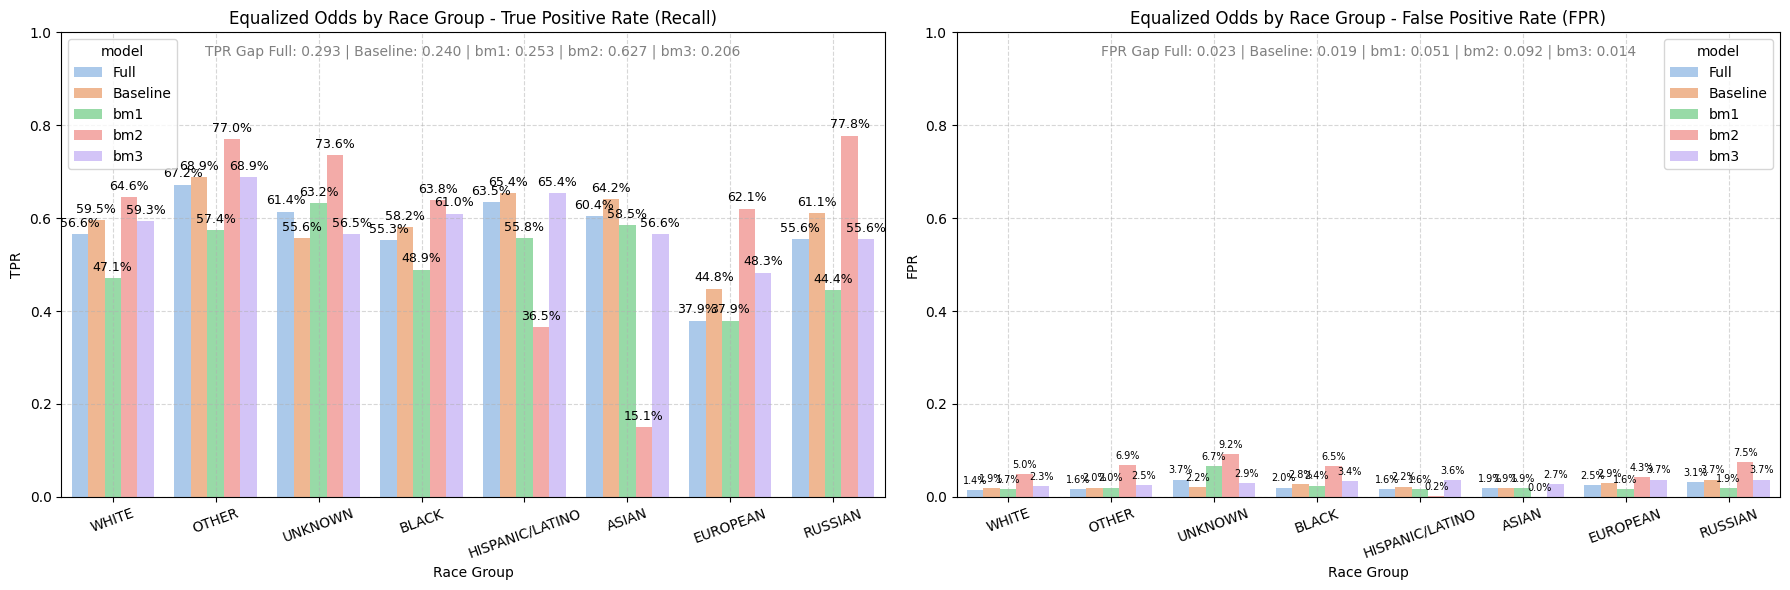

In [354]:
plot_equalized_odds(gender_comparison, group_col_name='Gender Group', title_prefix='Equalized Odds by Gender Group', figsize=(13, 6))
plot_equalized_odds(age_comparison, group_col_name='Age Group', title_prefix='Equalized Odds by Age Group', figsize=(15, 6))
plot_equalized_odds(race_comparison, group_col_name='Race Group', title_prefix='Equalized Odds by Race Group', figsize=(18, 6))

#### Calibration

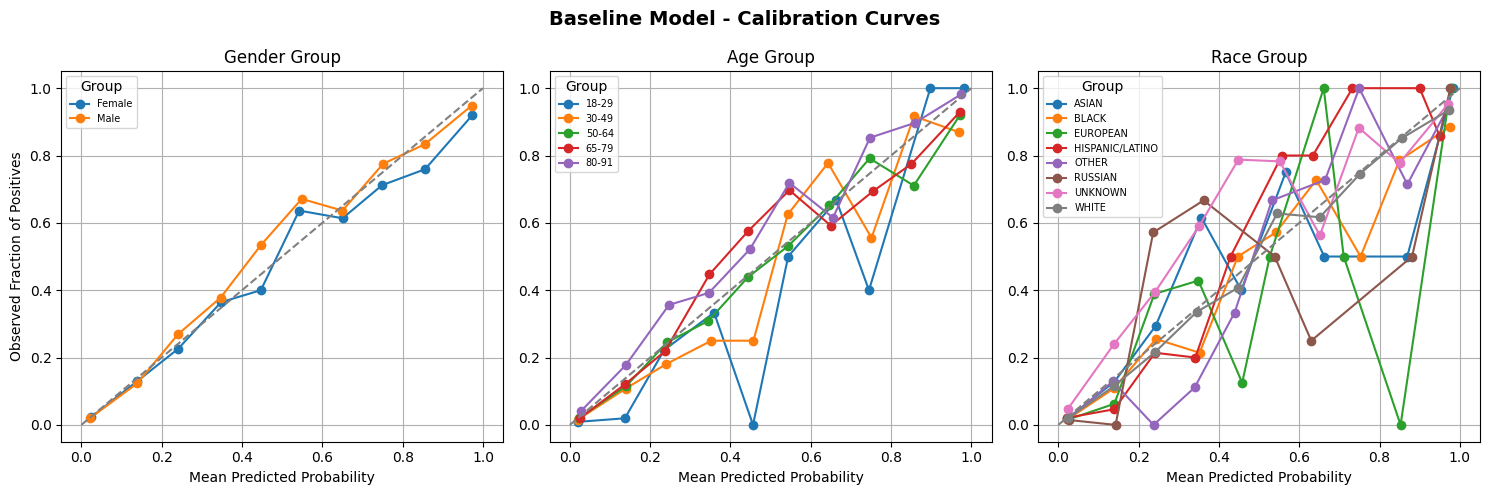

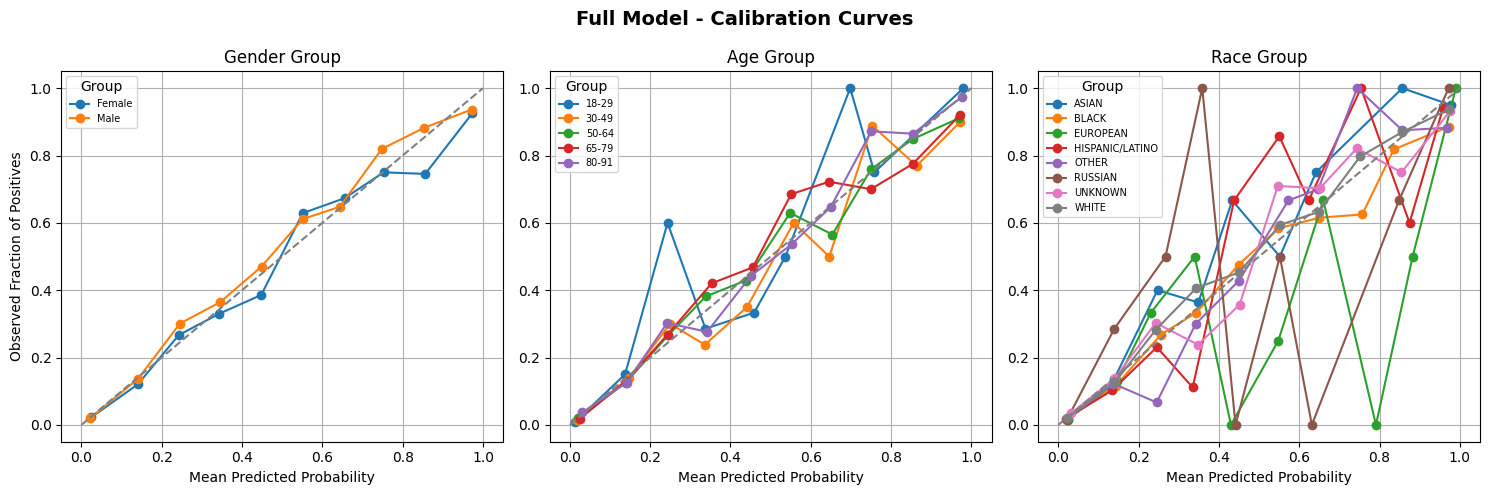

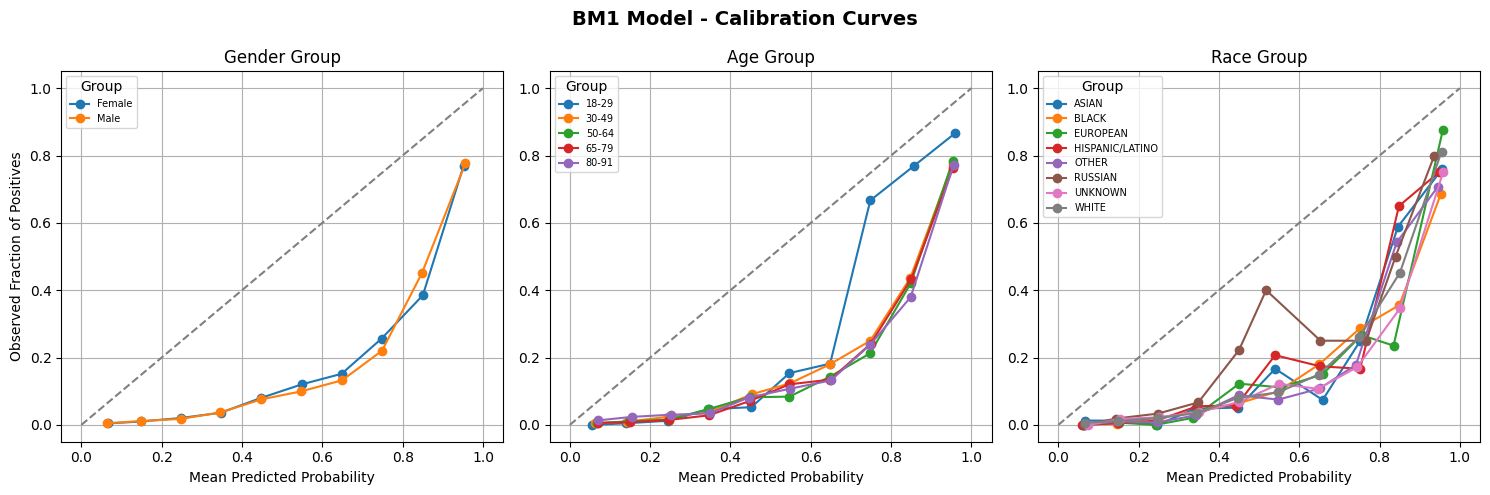

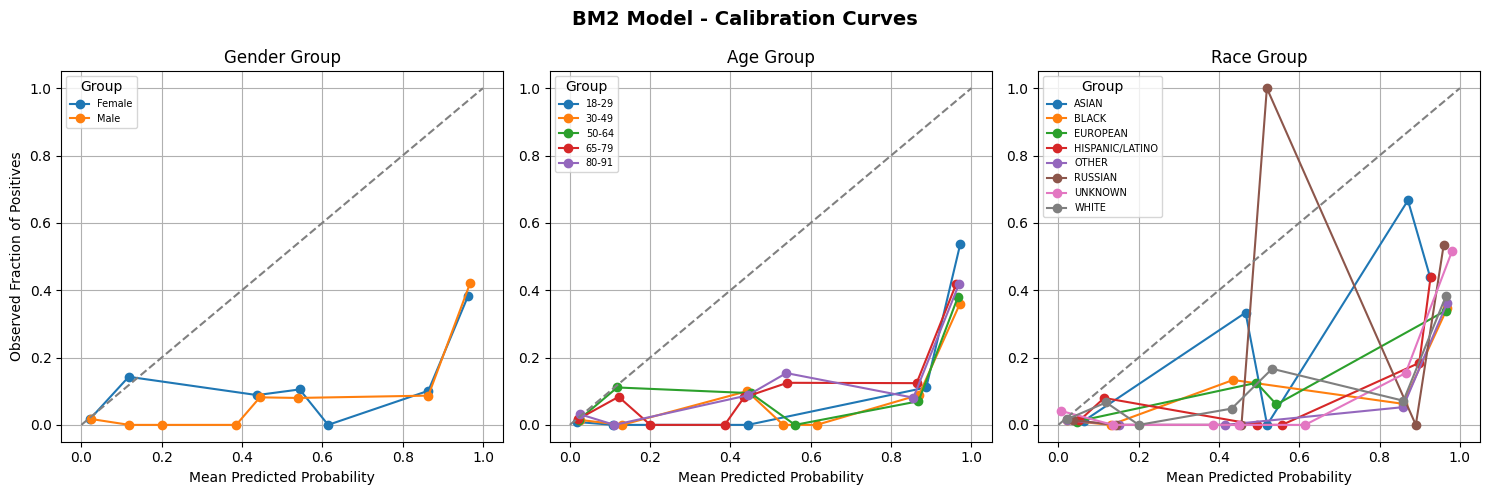

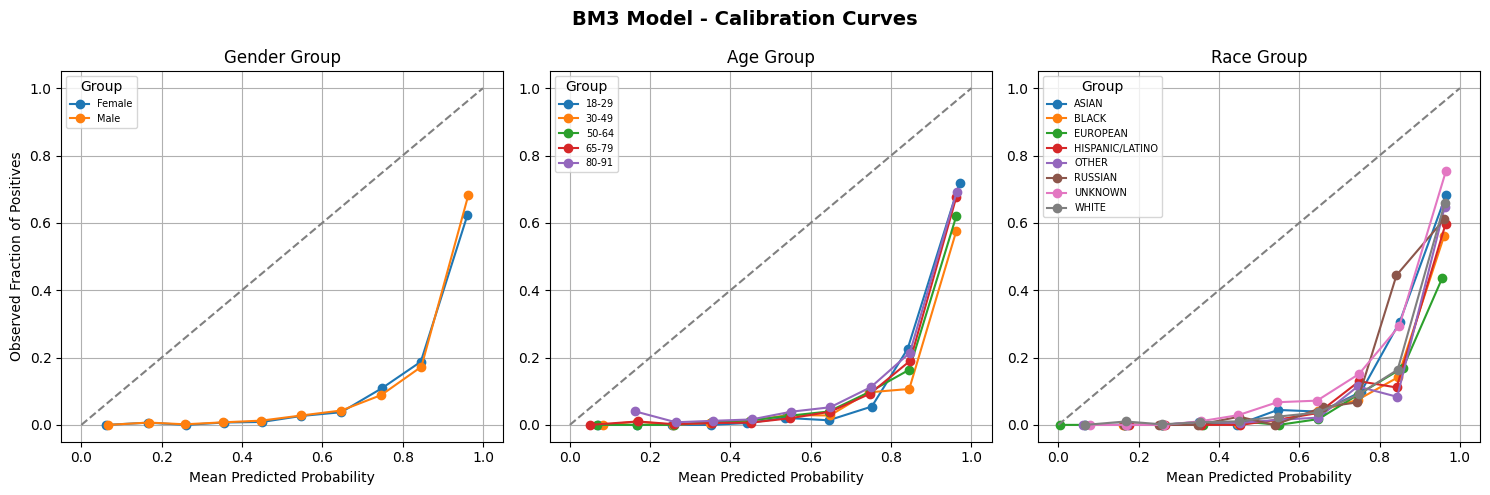

In [355]:
df_list = [df_test_baseline, df_test_full, df_test_bm1, df_test_bm2, df_test_bm3]
model_labels = ['Baseline', 'Full', 'BM1', 'BM2', 'BM3']

for df, label in zip(df_list, model_labels):
    plot_calibration_comparison_row(df, label)


#### 	Fairness-Performance Tradeoff Analysis

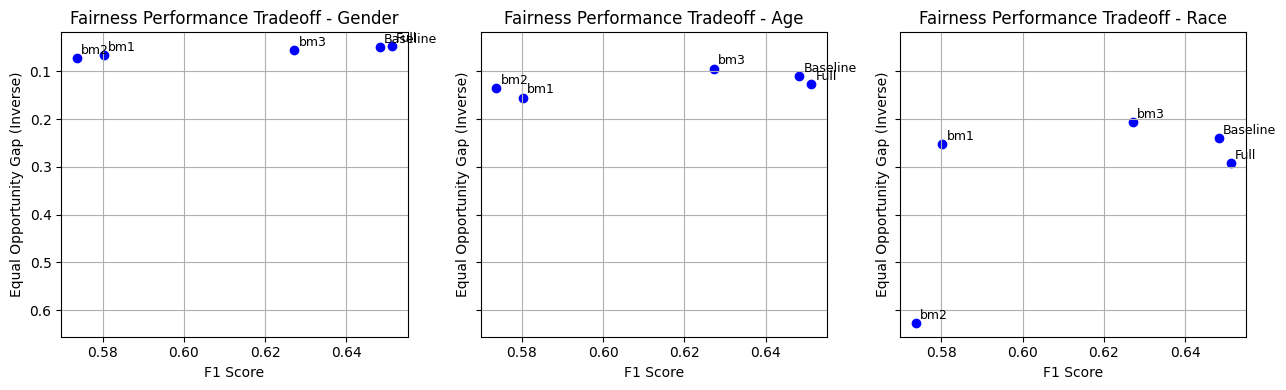

In [356]:
models = ['Baseline', 'Full', 'bm1', 'bm2', 'bm3']
f1_scores = [best_f1_baseline, best_f1_full, best_f1_bm1, best_f1_bm2, best_f1_bm3]
gender_gaps = [eo_gender_gap[model] for model in models]
age_gaps = [eo_age_gap[model] for model in models]
race_gaps = [eo_race_gap[model] for model in models]

fig, axs = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
titles = ['Fairness Performance Tradeoff - Gender', 'Fairness Performance Tradeoff - Age', 'Fairness Performance Tradeoff - Race']
ylabels = ['Equal Opportunity Gap (Inverse)', 'Equal Opportunity Gap (Inverse)', 'Equal Opportunity Gap (Inverse)']
gap_lists = [gender_gaps, age_gaps, race_gaps]

for ax, gaps, title, ylabel in zip(axs, gap_lists, titles, ylabels):
    ax.scatter(f1_scores, gaps, color='blue')
    for i, model in enumerate(models):
        ax.annotate(model, (f1_scores[i], gaps[i]), textcoords="offset points", xytext=(3,3), fontsize=9)
    ax.set_xlabel('F1 Score')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12)
    ax.grid(True)
    ax.invert_yaxis() # inversea

plt.tight_layout()
plt.show()